In [4]:
import math
import os
import pickle
import joblib
import random
import warnings
from functools import partial
from itertools import product

import numpy as np
import pandas as pd
import seaborn as sns
import torch
from matplotlib import pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable
from scipy import ndimage, stats
from scipy.optimize import curve_fit
from scipy.spatial.distance import cosine
from scipy.stats import (
    binned_statistic,
    binned_statistic_2d,
    pearsonr,
    spearmanr,
    ttest_ind,
    wilcoxon,
)
from sklearn.metrics import r2_score
from skimage import morphology
from statsmodels.stats.multitest import multipletests
from tqdm import tqdm

import torch.nn.functional as F
from torch import nn
import torch.optim as optim

import datajoint as dj

from staticnet_analyses import base
from staticnet_invariance import deis_reconfigured as deis_schema
from staticnet_pilots.analyses import *
from staticnet_pilots.analyses import DynamicStaticClosedLoopSummary
from featurevis.ops import center_and_crop_image

nfs = dj.create_virtual_module('nfs', 'neurodata_foundation_static')
collection = dj.create_virtual_module('collection', 'pipeline_collection')
meso = dj.create_virtual_module('meso', 'pipeline_meso')
fnn = dj.create_virtual_module('fnn', 'foundation_fnn')

def cal_dof(x,y):
    a = x.std()**2/len(x)
    b = y.std()**2/len(y)
    return (a+b)**2 / (a**2/(len(x)-1) + b**2/(len(y)-1))

# x,y has format n_pts*n_repeats(or observations)
def get_stat(x, y, alternative='two-sided'):
    print(wilcoxon(x.mean(axis=1),y.mean(axis=1), alternative=alternative))
    print('DOF: {:.2f}'.format(np.nanmean([cal_dof(i,j) for i,j in zip(x,y)])))

    stats = np.array([ttest_ind(i,j,equal_var=False, alternative=alternative) for i,j in zip(x,y)])
    temp = stats[:,0][stats[:,1]<0.05]
    print('Prior correction: Different {} {:.2f}% Less {} {:.2f}%, Greater {} {:.2f}%'.format(len(temp), len(temp)/len(x)*100, (temp<0).sum(), (temp<0).sum()/len(x)*100, (temp>0).sum(), (temp>0).sum()/len(x)*100))

    cr_temp = stats[:,0][multipletests(stats[:,1],0.05,method="fdr_bh")[0]]
    print('Post correction: Different {} {:.2f}% Less {} {:.2f}%, Greater {} {:.2f}%'.format(len(cr_temp), len(cr_temp)/len(x)*100, (cr_temp<0).sum(), (cr_temp<0).sum()/len(x)*100, (cr_temp>0).sum(), (cr_temp>0).sum()/len(x)*100))

# Load data

In [ ]:
additional_data = joblib.load("V1_L2_3_graph.joblib")

with open('/dj-stor01/users/zhiwei/closed_loop_bad_matching_neurons_by_visual_inspection_on_summary_images.pickle', 'rb') as handle:
    manual_exclude_dic = pickle.load(handle)
    
manual_exclude = []
for key, val in zip(manual_exclude_dic.keys(), manual_exclude_dic.values()):
    if key.split('-')[0] in ['30417', '30418', '31002']:
        manual_exclude.extend([dict(animal_id=key.split('-')[0], session=key.split('-')[1], scan_idx=key.split('-')[2], neuron_id=n) for n in val])

neuron_rel = \
(DynamicStaticClosedLoopSummary & 'dyn_match_unit_id = sta_match_unit_id and dyn_match_distance < 10 and sta_match_distance < 10 and src_match_distance < 10 and sta_match_corr >= 0.42 and dyn_match_corr >=0.42 and src_match_corr >= 0.42').proj() - \
(DynamicStaticClosedLoopSummary & ((DEIClosedLoopSummaryResults.Neuron & manual_exclude).proj(sta_neuron_id='neuron_id', sta_group_id='group_id'))).proj()

In [7]:
DynamicStaticClosedLoopSummary()

animal_id id number,session session index for the mouse,scan_idx number of TIFF stack file,dyn_session,dyn_scan_idx,dyn_unit_id,dyn_group_id,dyn_neuron_id,sta_session,sta_scan_idx,sta_unit_id,sta_group_id,sta_neuron_id,src_match_corr,src_match_distance,dyn_match_unit_id,dyn_match_corr,dyn_match_distance,sta_match_unit_id,sta_match_corr,sta_match_distance
30417,4,4,3,8,6,344,4,3,9,1714,342,1537,1.0,2.75658,5342,1.0,1.75957,5342,0.45774,4.57937
30417,4,4,3,8,54,344,42,3,9,2360,342,2117,1.0,2.76834,892,1.0,4.30139,892,-0.020837,1.44894
30417,4,4,3,8,183,344,158,3,9,2440,342,2190,1.0,2.5467,5506,1.0,2.94761,1055,0.312752,3.64836
30417,4,4,3,8,844,344,771,3,9,2010,342,1797,1.0,2.84753,5658,1.0,2.25887,5658,0.159709,3.03667
30417,4,4,3,8,956,344,862,3,9,5215,342,4628,1.0,2.8089,1872,1.0,2.51875,80,0.368601,2.38958
30417,4,4,3,8,1047,344,944,3,9,5639,342,4992,1.0,3.20716,164,1.0,4.17245,164,0.215439,3.4723
30417,4,4,3,8,1048,344,945,3,9,5297,342,4698,1.0,2.85096,1952,1.0,2.73012,165,0.229802,2.69246
30417,4,4,3,8,1495,344,1333,3,9,5774,342,5119,1.0,2.41555,710,1.0,3.29038,710,0.331013,2.84814
30417,4,4,3,8,1763,344,1575,3,9,6005,342,5322,1.0,2.55181,1917,1.0,2.78172,129,0.232698,3.71866
30417,4,4,3,8,2014,344,1796,3,9,6255,342,5539,1.0,2.78333,5612,1.0,1.93814,5612,0.127879,2.1736


# Helper functions

In [6]:
def plot_helper(x,y,xlabel,ylabel,non_robust_fit=False,min_val = -0.6,max_val = 1,plot_fit=True):
    plt.figure(figsize=(5, 5), dpi=300)
    idxs = [i for i in range(len(x)) if x[i] is not None and y[i] is not None]
    x = np.array([x[i] for i in idxs])
    y = np.array([y[i] for i in idxs])
    from scipy.stats import wilcoxon
    print(wilcoxon(x,y))
    from scipy.stats import pearsonr
    print(pearsonr(x,y))

    plt.scatter(x, y,color='k', s=20, marker='o',alpha=0.3,linewidth=0,label='Pearson r 95% CI: [{:.2f},{:.2f}]'.\
                format(*np.array(pearsonr(x,y).confidence_interval(confidence_level=0.95)).squeeze()))
    plt.plot([min_val, max_val], [min_val, max_val], color='k', linestyle='dashed')
    if plot_fit:
        x = x[:, np.newaxis]
        x_ = np.linspace(min_val,max_val,1000)


        if non_robust_fit:
            import statsmodels.api as sm
            alpha = 0.05
            lr = sm.OLS(y,x).fit()
            conf_interval = lr.conf_int(alpha).squeeze()
            coef = lr.params.item()
            plt.plot(x_, coef*x_, color='k', label='Linear fit: y = {:.2f} x, 95% CI:[{:.2f},{:.2f}]'.format(coef,*conf_interval))
        else:
            from sklearn import linear_model
            # robust fit
            all_coefs = []
            for i in tqdm(range(1000)):
                ransac = linear_model.RANSACRegressor(base_estimator=linear_model.LinearRegression(fit_intercept=False), max_trials=1000)
                ransac.fit(x, y)
                all_coefs.append(ransac.estimator_.coef_.item())
            coef = np.mean(all_coefs) #median?
            std = np.std(all_coefs)

            plt.plot(x_, coef*x_, color='k', label='Linear fit: y = {:.2f} x \u00B1 {:.2f}'.format(coef,std))
        plt.legend(loc=2)
    else:
        coef = None
    plt.xlabel(xlabel, fontsize=14)
    plt.ylabel(ylabel, fontsize=14)



    plt.xlim(min_val,max_val)
    plt.ylim(min_val,max_val)

    sns.despine()
    plt.tight_layout()
    plt.show()
    return pearsonr(x.squeeze(),y), coef

def convert_score(scores,lower_bound=7.72,upper_bound=13.92):
    return (scores-lower_bound)/(upper_bound-lower_bound)

def process_helper(process_name='switch_sign'):
    if process_name == 'switch_sign':
        return lambda x: -x
    elif process_name == 'complexity_fourier':
        return find_n_components
    elif process_name == 'complexity_jpeg':
        return cal_compress_complexity
    elif process_name == 'difference':
        return lambda x,y: y-x
    elif process_name == 'abs':
        return lambda x: abs(x)
    elif process_name == 'None':
        return lambda x: x
    elif process_name == 'avg_pairwise_cosine_similarity':
        def avg_pairwise_dist(x,y):
            if len(x.shape)>2:
                x = x.reshape(len(x),-1)
            if len(y.shape)>2:
                y = y.reshape(len(x),-1)
            from scipy.spatial.distance import cdist
            return 1.0-cdist(x,y,metric='cosine').mean()
        return avg_pairwise_dist
    elif process_name == 'cosine_similarity':
        from scipy.spatial.distance import cosine
        return lambda x,y: 1-cosine(x.ravel(),y.ravel())
    elif process_name == 'avg_cosine_similarity':
        from scipy.spatial.distance import cdist
        return lambda x,y: 1.0-cdist(x,y,metric='cosine').mean()
    elif process_name == 'sum':
        return np.sum
    elif process_name == 'euclidean_distance':
        from scipy.spatial.distance import euclidean
        return euclidean
    elif process_name == 'sim_normalize_by_x':
        return lambda x,y: (x*y).sum()/(x.sum()+1e-9)
    
# Unit_key should be string in the format of session_scan_unit
# Helper function to find attribute and process it accordingly by string key
def get_summary(unit_key,summary_data,name_keys=('avg_sim','None')):
    search_name = name_keys[0]

    # Find the appropriate process function
    fs = [process_helper(i) for i in name_keys[1:]]
    attribute = summary_data[unit_key][search_name]
    for f in fs:
        attribute = f(attribute)
        
    try:
        return attribute.item()
    except:
        return attribute

def get_all_random_key_helper(connectivity_datas,pre_unit_key):
    # all_random_keys = [set(data['post_unit_key'].to_numpy()) for data in connectivity_datas]+\
    # [set(data['pre_unit_key'].to_numpy()) for data in connectivity_datas]
    all_random_keys = [set(data['post_unit_key'].to_numpy()) for data in connectivity_datas]
    all_random_keys = set().union(*all_random_keys)
#    all_random_keys = all_random_keys - set.union(*[set(data['pre_unit_key'].to_numpy()) for data in connectivity_datas])
    all_remove_keys = [set(data[data['pre_unit_key']==pre_unit_key]['post_unit_key'].to_numpy()) for data in connectivity_datas]
    all_remove_keys = set().union(*all_remove_keys)
    all_remove_keys.add(pre_unit_key)
    
    all_random_keys = all_random_keys - all_remove_keys
    return np.array(list(all_random_keys),dtype='<U8')

from numpy.fft import fft2, ifft2,ifftshift,fftshift,fftfreq
def standardize_img(img):
    return (img - img.mean()) / (img.std()+1e-9)

def cal_power_spectrum(img):
    img = standardize_img(img)
    mag = np.abs(fftshift(fft2(img)))
    return mag

def find_n_components(img,threshold=0.9):
    img = img[:36,:64]
    mag = cal_power_spectrum(img)
    fraction_explained = np.cumsum(np.sort(mag.ravel())[::-1])/mag.ravel().sum()
    return np.where(fraction_explained>threshold)[0][0]

def cal_compress_complexity(x,quality=95):
    import numpy as np
    from PIL import Image
    import os

    def convert_8bit(x,std_threshold = 8):
        x = x.astype(np.float32)
        min_clip = x.mean() - std_threshold*x.std()
        max_clip = x.mean() + std_threshold*x.std()
        x = np.clip(x,min_clip,max_clip)
        x -= min_clip
        x = ((255. / (max_clip - min_clip)) * x).astype(np.uint8)
        return x
    
    x = x[:36,:64]
    x = convert_8bit(x)
    x = Image.fromarray(x)
    x.save('image.jpg',quality=quality)
    size = os.path.getsize('image.jpg')
    os.remove('image.jpg')
    return size
def bootstrap_bin(data, var='mei_sim',corrected=True):
    results = {}
    if corrected:
        x = (data[var]-data.groupby("pre_nucleus_id")[var].transform('mean'))
        x = (x + data[var].mean()).to_numpy()

        y = (data['n_synapses'] - data['dend_len'] 
             * data.groupby("pre_nucleus_id")['n_synapses'].transform("sum")
             /data.groupby("pre_nucleus_id")['dend_len'].transform("sum"))
        y = (y + data['n_synapses'].sum()/data['dend_len'].sum()*data['dend_len']).to_numpy()
    else:
        x = data[var]
        y = data['n_synapses']

    z = (data['dend_len'] / 1e6).to_numpy() 
    bin_edges = np.linspace(np.percentile(x,5),np.percentile(x,95),7)
    _,_,bin_idxs = binned_statistic(x, x, statistic='mean', bins=bin_edges)
    data = np.stack([x,y,z,bin_idxs]).T
    var_data = pd.DataFrame(data = data,columns= ['corrected_sim','corrected_n_synapse','dend_len','bin_idx'])
    ratios = []
    np.random.seed(0)
    for _ in tqdm(range(10000)):
        bs_data = var_data.sample(frac=1, replace=True, random_state=np.random.randint(10000000))
        binned_data = (
            bs_data.groupby("bin_idx")
            .agg(
                numerator=('corrected_n_synapse', "sum"),
                denominator=('dend_len', "sum"),
            )
            .reset_index()
            .assign(
                quantity=lambda x: x["numerator"] / x["denominator"],
            )
        )
        # Remove the top and bottom bin
        binned_data = binned_data[np.logical_and(binned_data['bin_idx']>binned_data['bin_idx'].min(), binned_data['bin_idx']<binned_data['bin_idx'].max())]
        ratios.append(binned_data['quantity'].to_numpy())
    ratios = np.stack(ratios)
    results['x_center'] = (bin_edges[1:] + bin_edges[:-1])/2
    results['y_center'] = ratios.mean(axis=0)
    results['y_CI'] = np.array([get_CI(ratios[:,i]) for i in range(ratios.shape[1])])
    return results
def test_agg(summary_data,test_type = 'connected_vs_adp',name_keys=('avg_sim','None'),f= process_helper('difference'),
             xlabel='Bootstrapped median diversity difference \nbetween connected and ADP pairs',
             sampled_by_prior=True,
             summary_f = np.mean,
             return_aux_result=False,
             n_bootstrap=10000):
    
    if test_type == 'connected_vs_adp':
        x_keys = connected_keys
        y_keys = adp_keys
        x_sample_ps = connected_ps
        y_sample_ps = adp_ps
    elif test_type == 'adp_vs_random':
        x_keys = adp_keys
        y_keys = random_keys
        x_sample_ps = adp_ps
        y_sample_ps = None
    elif test_type == 'shuffle_connected_vs_shuffle_adp':
        x_keys = shuffle_connected
        y_keys = shuffle_adp
        x_sample_ps = connected_ps
        y_sample_ps = adp_ps
    else:
        raise ValueError()
        
    x,y,x_ps,y_ps = [],[],[],[]
    
    for pre_unit_key in tqdm(pre_unit_keys):
        pre_attribute = get_summary(pre_unit_key,summary_data,name_keys=name_keys)
        if x_sample_ps is not None:
            x_ps.append(x_sample_ps[pre_unit_key])
        if y_sample_ps is not None:
            y_ps.append(y_sample_ps[pre_unit_key])
            
        for key in x_keys[pre_unit_key]:
            x.append(f(pre_attribute,get_summary(key,summary_data,name_keys=name_keys)))
        for key in y_keys[pre_unit_key]:
            y.append(f(pre_attribute,get_summary(key,summary_data,name_keys=name_keys)))
            
    x = np.array(x)
    y = np.array(y)
    
    if x_sample_ps is None or not sampled_by_prior:
        x_ps = None
    else:
        x_ps = np.concatenate(x_ps)
        x_ps = x_ps/np.sum(x_ps)
        
    if y_sample_ps is None or not sampled_by_prior:
        y_ps = None
    else:
        y_ps = np.concatenate(y_ps)
        y_ps = y_ps/np.sum(y_ps)
    
    np.random.seed(0)
    x_summary,y_summary = [],[]
    for i in range(n_bootstrap):
        x_ = np.random.choice(x,len(x),replace=True,p=x_ps)
        y_ = np.random.choice(y,len(y),replace=True,p=y_ps)
        x_summary.append(summary_f(x_))
        y_summary.append(summary_f(y_))
        
    x_summary = np.array(x_summary)
    y_summary = np.array(y_summary)
    
    summary_diffs = x_summary-y_summary

    xlim = max(abs(summary_diffs.max()),abs(summary_diffs.min()))
    sns.histplot(summary_diffs,bins=50,color='gray',stat='probability',linewidth=0,binrange=[-xlim,xlim])
    sns.despine()
    p_tests = {'<0':np.around((summary_diffs<0.0).sum()/len(summary_diffs),2),
               '>0':np.around((summary_diffs>=0.0).sum()/len(summary_diffs),2)}
    # plt.axvline(x=0.0,color='k',linestyle = '--',label='{}:{:.4f}'.format(min(p_tests, key=p_tests.get),min(list(p_tests.values()))))
    plt.axvline(x=0.0,color='k',linestyle = '--',label='p:{:.4f}'.format(2*min(list(p_tests.values()))))

    plt.xlabel(xlabel)
    plt.legend()
    plt.show()
    if return_aux_result:
        return x,y,x_summary,y_summary,min(list(p_tests.values()))*2

def test_agg_with_provided_stat(x,y,x_ps=None,y_ps=None,
             xlabel='Bootstrapped median diversity difference \nbetween connected and ADP pairs',
                                return_aux_result = False,
             sampled_by_prior=True,
             summary_f = np.mean,
             n_bootstrap=10000):
            
      
            
    x = np.array(x)
    y = np.array(y)
    
    np.random.seed(0)
    x_summary,y_summary = [],[]
    for i in range(n_bootstrap):
        x_ = np.random.choice(x,len(x),replace=True,p=x_ps)
        y_ = np.random.choice(y,len(y),replace=True,p=y_ps)
        x_summary.append(summary_f(x_))
        y_summary.append(summary_f(y_))
        
    x_summary = np.array(x_summary)
    y_summary = np.array(y_summary)
    
    summary_diffs = x_summary-y_summary

    xlim = max(abs(summary_diffs.max()),abs(summary_diffs.min()))
    sns.histplot(summary_diffs,bins=50,color='gray',stat='probability',linewidth=0,binrange=[-xlim,xlim])
    sns.despine()
    p_tests = {'<0':np.around((summary_diffs<0.0).sum()/len(summary_diffs),2),
               '>0':np.around((summary_diffs>=0.0).sum()/len(summary_diffs),2)}
    # plt.axvline(x=0.0,color='k',linestyle = '--',label='{}:{:.4f}'.format(min(p_tests, key=p_tests.get),min(list(p_tests.values()))))
    plt.axvline(x=0.0,color='k',linestyle = '--',label='p:{:.4f}'.format(2*min(list(p_tests.values()))))

    plt.xlabel(xlabel)
    plt.legend()
    plt.show()
    if return_aux_result:
        return x,y,x_summary,y_summary,min(list(p_tests.values()))*2
    
def get_CI(x,ci=95):
    return np.percentile(x,(100-ci)/2),np.percentile(x,100-(100-ci)/2)

def bootstrap_comp(data, var='mei_sim',corrected=True,seed=0):
    # Connected pair
    temp = data[data['n_synapses']>0]
    if corrected:
        x = (temp[var]-temp.groupby("pre_nucleus_id")[var].transform('mean'))
        x = (x + temp[var].mean()).to_numpy()
    else:
        x = temp[var].to_numpy()
    
    if corrected:
        xs = (data['n_synapses'] - data['dend_len'] 
         * data.groupby("pre_nucleus_id")['n_synapses'].transform("sum")
         /data.groupby("pre_nucleus_id")['dend_len'].transform("sum"))
        xs = (xs + data['n_synapses'].sum()/data['dend_len'].sum()*data['dend_len']).to_numpy()
        xs = xs[(data['n_synapses']>0).to_numpy()]
    else:
        xs = temp['n_synapses'].to_numpy()
        
    xs = xs/xs.sum()
    
    # ADP pair
    temp = data[data['n_synapses']==0]
    if corrected:
        y = (temp[var]-temp.groupby("pre_nucleus_id")[var].transform('mean'))
        y = (y + temp[var].mean()).to_numpy()
    else:
        y = temp[var].to_numpy()
        
    ys = temp['dend_len'].to_numpy()
    ys = ys/ys.sum()
    # Bootstrap
    np.random.seed(seed)
    X = np.stack([x,xs]).T
    Y = np.stack([y,ys]).T
    x_summary,y_summary = [],[]
    for i in tqdm(range(10000)):
        idx = np.random.choice(len(X),len(X),replace=True)
        x_summary.append((X[idx,0]* X[idx,1]).sum())
        idx = np.random.choice(len(Y),len(Y),replace=True)
        y_summary.append((Y[idx,0]* Y[idx,1]).sum())
    x_summary = np.array(x_summary)
    y_summary = np.array(y_summary)
    
    summary_diffs = x_summary-y_summary
    p_tests = {'<0':np.around((summary_diffs<0.0).sum()/len(summary_diffs),2),
               '>0':np.around((summary_diffs>=0.0).sum()/len(summary_diffs),2)}
    p = 2*min(list(p_tests.values()))
    return x_summary,y_summary,p

# 6c-d

In [3]:
def get_real_resps(subtype='mei'):
    result_rel = DEIClosedLoopSummaryResults.Subtype.proj('real_response', dyn_group_id='group_id', dyn_neuron_id='neuron_id')
    comb_rel = result_rel * neuron_rel & {'subtype': subtype}
    # dynamic model performance on dynamic and static oracles
    dyn_resp, dyn_cc_abs, dyn_cc_max, dyn_cc_norm, dyn_sta_cc_abs, dyn_sta_cc_max, dyn_sta_cc_norm = \
    (comb_rel.proj('real_response', unit_id='dyn_unit_id', mei_session='session', mei_scan_idx='scan_idx') * \
    nfs.FoundationEval.UnitDynamic * \
    nfs.FoundationEval.UnitStatic
    ).fetch('real_response', 'dyn_cc_abs', 'dyn_cc_max', 'dyn_cc_norm', 'sta_cc_abs', 'sta_cc_max', 'sta_cc_norm', order_by='dyn_group_id, dyn_neuron_id')
    return dyn_resp, dyn_cc_abs, dyn_cc_max, dyn_cc_norm, dyn_sta_cc_abs, dyn_sta_cc_max, dyn_sta_cc_norm

In [4]:
dyn_mei, dyn_cc_abs, dyn_cc_max, dyn_cc_norm, dyn_sta_cc_abs, dyn_sta_cc_max, dyn_sta_cc_norm = get_real_resps()

In [5]:
dyn_dei, _, _, _, _, _, _ = get_real_resps('deis')

In [6]:
dyn_pdei, _, _, _, _, _, _ = get_real_resps('local_deis')

In [11]:
get_stat(np.stack(dyn_mei)*0.85, np.stack(dyn_dei))

WilcoxonResult(statistic=31534.0, pvalue=0.0002840916688895511)
DOF: 32.04
Prior correction: Different 41 10.28% Less 4 1.00%, Greater 37 9.27%
Post correction: Different 1 0.25% Less 0 0.00%, Greater 1 0.25%


In [12]:
get_stat(np.stack(dyn_pdei), np.stack(dyn_dei))

WilcoxonResult(statistic=29878.0, pvalue=1.3750596920097997e-05)
DOF: 32.03
Prior correction: Different 38 9.52% Less 25 6.27%, Greater 13 3.26%
Post correction: Different 0 0.00% Less 0 0.00%, Greater 0 0.00%


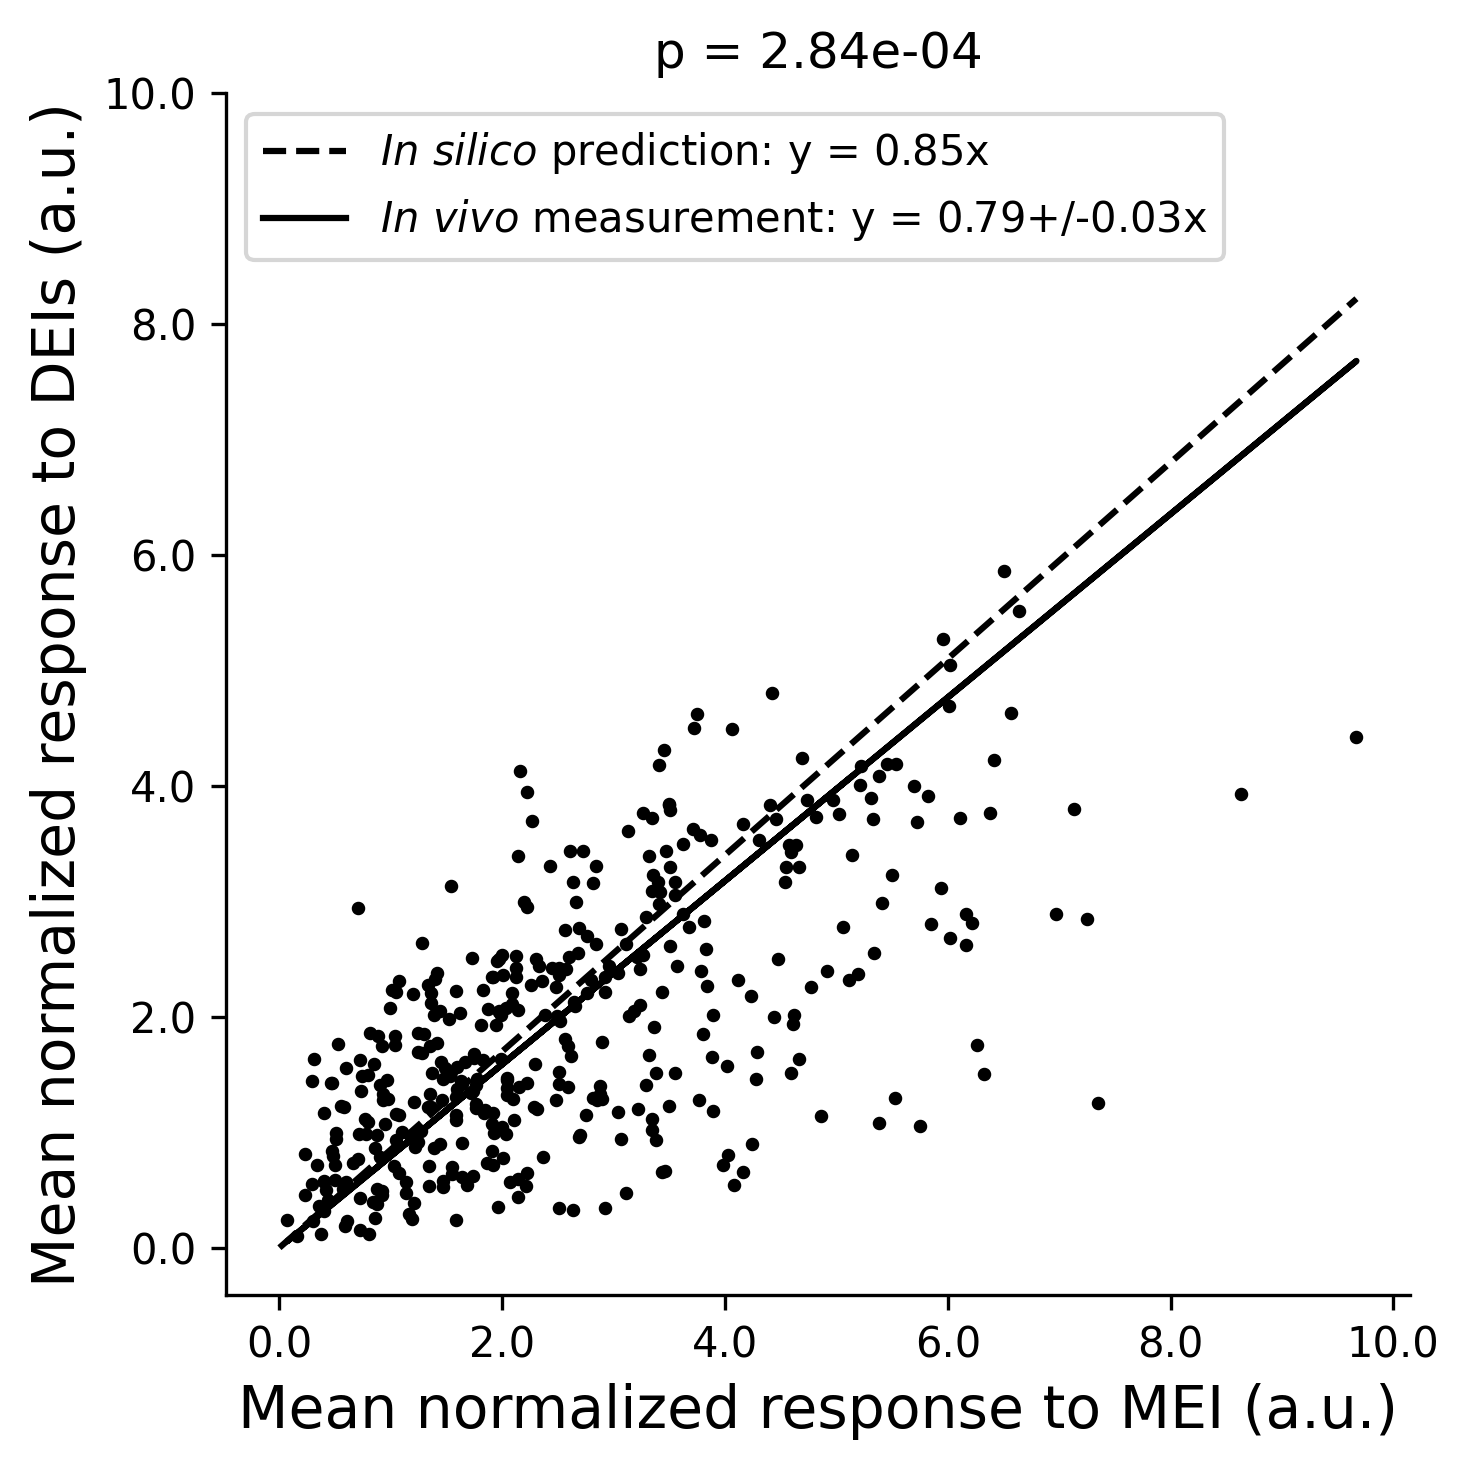

In [14]:
l = 'MEI'
x_mean = np.stack(dyn_mei).mean(-1)
x_std = np.stack(dyn_mei).std(-1)
dei_mean = np.stack(dyn_dei).mean(-1)
dei_std = np.stack(dyn_dei).std(-1)
n_repeats = 20

plt.figure(figsize=(5, 5), dpi=300)

ps = np.array([scipy.stats.ttest_ind_from_stats(m1*0.85,s1*0.85,n_repeats,m2,s2,n_repeats, equal_var=False)[1] for m1,s1,m2,s2 in zip(x_mean, x_std, dei_mean, dei_std)])
p_wc = scipy.stats.wilcoxon(x_mean*0.85, dei_mean)[1]
plt.scatter(x_mean[ps>0.05], dei_mean[ps>0.05], color='k', s=5, marker='o')#, label='p > 0.05')
plt.scatter(x_mean[ps<=0.05], dei_mean[ps<=0.05], color='k', s=5, marker='o')#, label=r'$p \leq 0.05$')

max_val = np.concatenate([x_mean, dei_mean]).max()
plt.plot([0, max_val], [0, max_val*0.85], color='k', linestyle='dashed', label='$In\ silico$ prediction: y = 0.85x')

# Linear fit 
from sklearn import linear_model
x = x_mean[:, np.newaxis]
# robust fit
coefs = []
for i in range(1000):
    ransac = linear_model.RANSACRegressor(base_estimator=linear_model.LinearRegression(fit_intercept=False), max_trials=1000)
    ransac.fit(x, dei_mean)
    coefs.append(ransac.estimator_.coef_.item())
coef = np.mean(coefs)
std_coef = np.std(coefs) 

plt.plot(x_mean, coef*x_mean, color='k', label='$In\ vivo$ measurement: y = {:.2f}+/-{:.2f}x'.format(coef, std_coef))

plt.xlabel('Mean normalized response to {} (a.u.)'.format(l), fontsize=14)
plt.ylabel('Mean normalized response to DEIs (a.u.)', fontsize=14)

plt.title('p = {}'.format(np.format_float_scientific(p_wc, precision=2)))
tick_labels = np.round(np.linspace(0, np.ceil(max_val), 6), 1)
plt.xticks(tick_labels, tick_labels)
plt.yticks(tick_labels, tick_labels)

plt.legend(loc=2)
sns.despine()
plt.tight_layout()
# plt.axis('equal')
plt.savefig('/src/notebooks/Official_figures/[Fig6_c]In_vivo_comparison_of_DS_DEI_and_DS_{}_responses.pdf'.format(l), transparent=True)


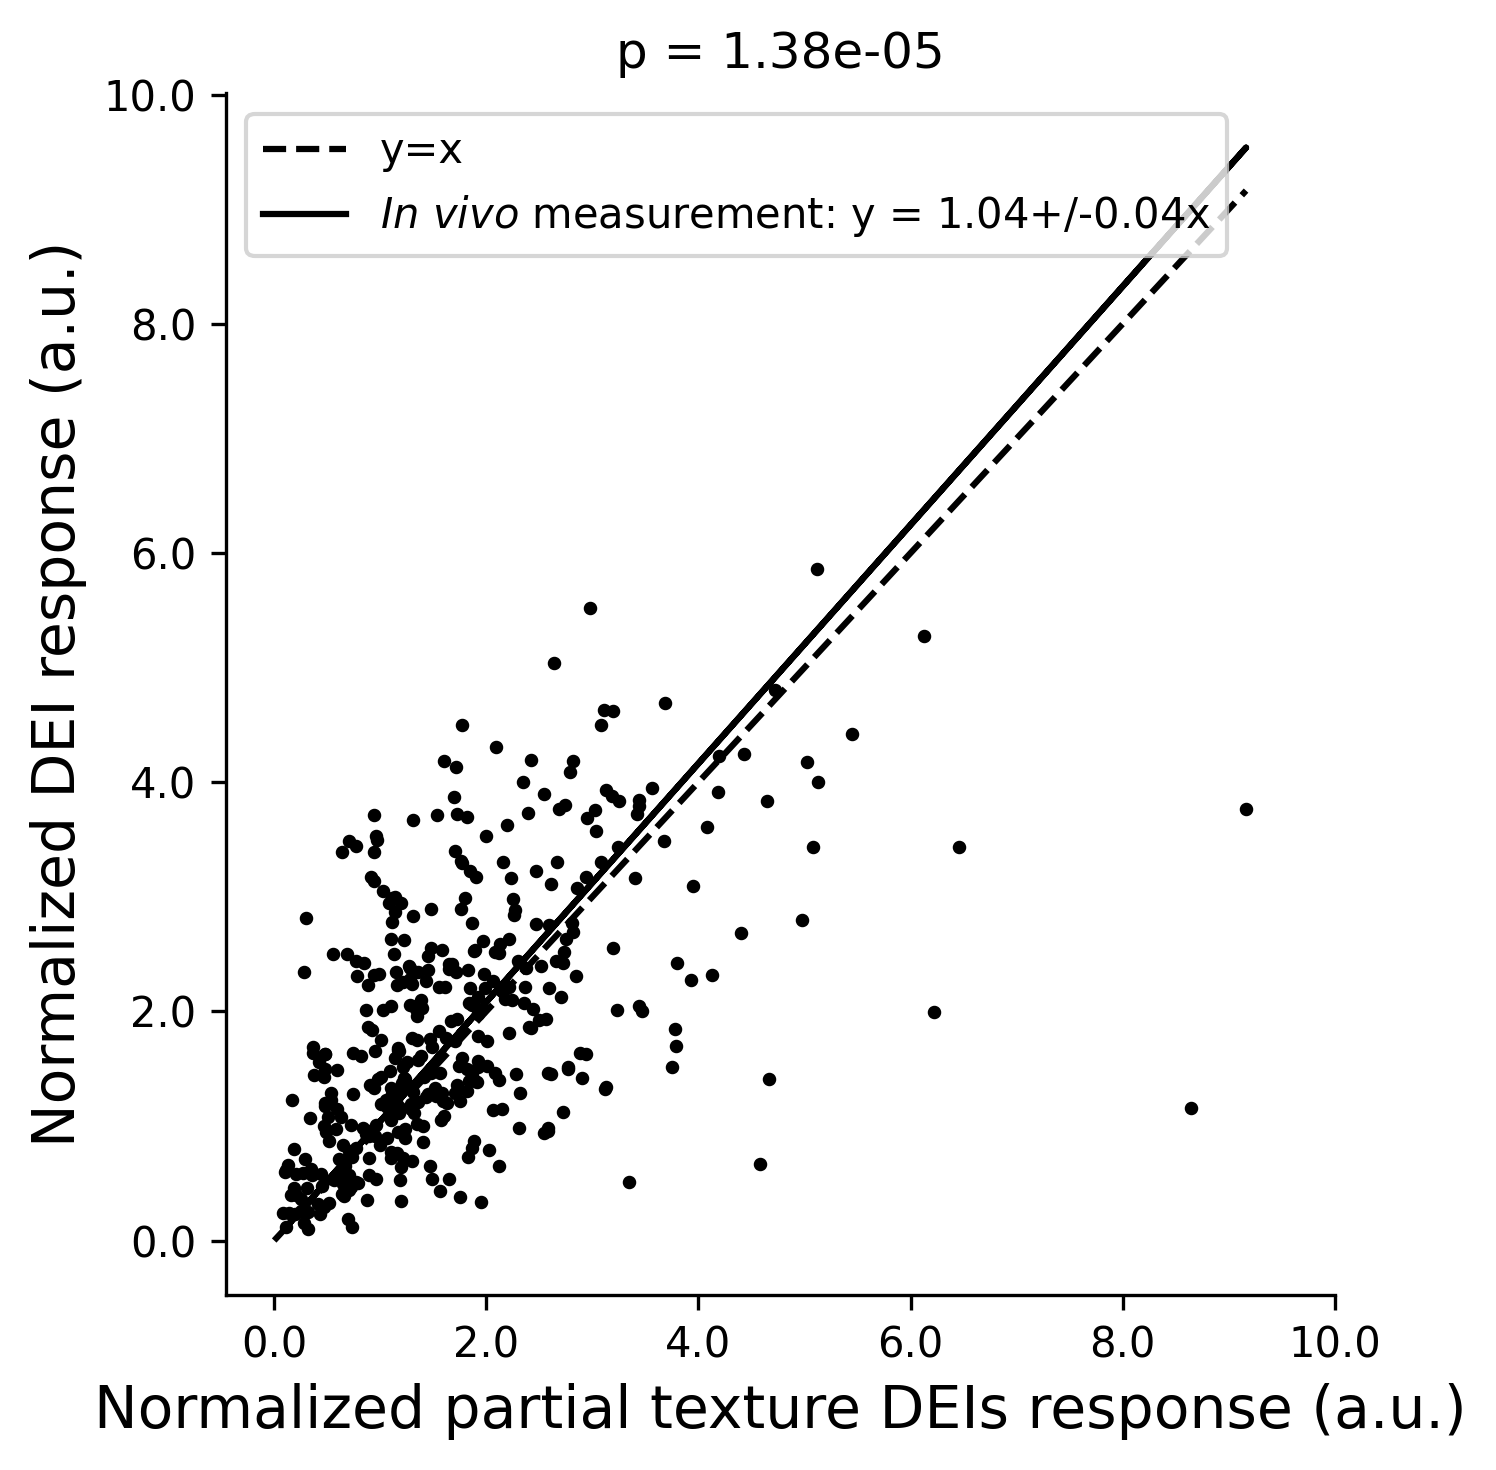

In [16]:
l = 'partial texture DEIs'
x_mean = np.stack(dyn_pdei).mean(-1)
x_std = np.stack(dyn_pdei).std(-1)
dei_mean = np.stack(dyn_dei).mean(-1)
dei_std = np.stack(dyn_dei).std(-1)
n_repeats = 20

plt.figure(figsize=(5, 5), dpi=300)

ps = np.array([scipy.stats.ttest_ind_from_stats(m1,s1,n_repeats,m2,s2,n_repeats, equal_var=False)[1] for m1,s1,m2,s2 in zip(x_mean, x_std, dei_mean, dei_std)])
p_wc = scipy.stats.wilcoxon(x_mean, dei_mean)[1]
plt.scatter(x_mean[ps>0.05], dei_mean[ps>0.05], color='k', s=5, marker='o')#, label='p > 0.05')
plt.scatter(x_mean[ps<=0.05], dei_mean[ps<=0.05], color='k', s=5, marker='o')#), label=r'$p \leq 0.05$')

max_val = np.concatenate([x_mean, dei_mean]).max()
plt.plot([0, max_val], [0, max_val], color='k', linestyle='dashed', label='y=x')

# Linear fit 
from sklearn import linear_model
x = x_mean[:, np.newaxis]
# robust fit
coefs = []
for i in range(1000):
    ransac = linear_model.RANSACRegressor(base_estimator=linear_model.LinearRegression(fit_intercept=False), max_trials=1000)
    ransac.fit(x, dei_mean)
    coefs.append(ransac.estimator_.coef_.item())
coef = np.mean(coefs)
std_coef = np.std(coefs) 
plt.plot(x_mean, coef*x_mean, color='k', label='$In\ vivo$ measurement: y = {:.2f}+/-{:.2f}x'.format(coef, std_coef))

plt.ylabel('Normalized DEI response (a.u.)', fontsize=14)
plt.xlabel('Normalized {} response (a.u.)'.format(l), fontsize=14)

plt.title('p = {}'.format(np.format_float_scientific(p_wc, precision=2)))
tick_labels = np.round(np.linspace(0, np.ceil(max_val), 6), 1)
plt.xticks(tick_labels, tick_labels)
plt.yticks(tick_labels, tick_labels)

plt.legend(loc=2)
sns.despine()
plt.tight_layout()
# plt.axis('equal')
plt.savefig('/src/notebooks/Official_figures/[Fig6_c]In_vivo_comparison_of_DS_DEI_and_DS_{}_responses.pdf'.format(l), transparent=True)


# 6e-f

# Comparison of DEIs from dynamic static model and static model

In [109]:
with open('/src/static-networks/dynamic_static_deis.pickle','rb') as handle:
    dic = pickle.load(handle)

In [110]:
image_types = ['Static', 'Dynamic static']

In [119]:
neural_representation = NeuralRepresentation()
mei_imgs = {i:[] for i in image_types}
mei_pc_coefs = {i:[] for i in image_types}
dei_imgs = {i:[] for i in image_types}
dei_xs = {i:None for i in image_types}
dei_ys = {i:None for i in image_types}
dei_divs = {i:None for i in image_types}
pc_coefs = {i:[] for i in image_types}


11-06-2024:03:13:56 INFO     configs.py           242:	 Ignoring input arguments: "net_hash", "core_hash", "ro_hash", "shift_hash", "mod_hash", "train_hash", "data_hash", "group_id", "seed", "train_type", "schedule", "max_epoch", "loss_type", "avg_loss"when creating datasets
11-06-2024:03:13:56 INFO     configs.py           222:	 Loading None dataset with tier=train
11-06-2024:03:13:56 INFO     data_schemas.py     1318:	 Fetching data for {'group_id': 285, 'description': 'Inserted from PipelineManagement'}
11-06-2024:03:13:56 INFO     data_schemas.py     1328:	 Data will be (images,behavior,pupil_center,responses)
11-06-2024:03:13:56 INFO     data_schemas.py     1331:	 Loading dataset group285-28120-4-9-9 --> /dj-stor01/cache/static28120-4-9-preproc9-spikemethod5.h5
11-06-2024:03:13:56 INFO     configs.py           227:	 Adding stats_source "all" to dataset
11-06-2024:03:13:56 INFO     configs.py           231:	 Using statistics source all
11-06-2024:03:13:56 INFO     configs.py       

In [120]:
for i in image_types:
    if i == 'Static':
        mei_imgs[i] = dic['sta_meis']
        dei_xs[i] = dic['sta_xs']
        dei_ys[i] = dic['sta_ys']
        dei_divs[i] = dic['sta_divs']
        dei_imgs[i] = dic['sta_deis']

    elif i == 'Dynamic static':
        mei_imgs[i] = dic['dyn_meis']
        dei_xs[i] = dic['dyn_xs']
        dei_ys[i] = dic['dyn_ys']
        dei_divs[i] = dic['dyn_divs']
        dei_imgs[i] = dic['dyn_deis']

    mei_pc_coefs[i] = np.stack([neural_representation.transform(mei,mask_x,mask_y,standardize_std=True).squeeze() for mei,mask_x,mask_y in zip(mei_imgs[i], dei_xs[i], dei_ys[i])])
    pc_coefs[i] = np.stack([neural_representation.transform(dei,mask_x,mask_y,standardize_std=True).squeeze() for dei,mask_x,mask_y in zip(dei_imgs[i], dei_xs[i], dei_ys[i])])


In [121]:
for i in image_types:
    print(i,mei_imgs[i].shape, mei_pc_coefs[i].shape, dei_imgs[i].shape, pc_coefs[i].shape)

Static (399,) (399, 53) (399,) (399, 20, 53)
Dynamic static (399,) (399, 53) (399,) (399, 20, 53)


In [122]:
N_DIM

53

In [123]:
# DEIs
ps = {i:None for i in image_types}
dist_matrices = {i:None for i in image_types}
for image_type in image_types:
    X = pc_coefs[image_type]
    dist_matrix = np.zeros([len(X),len(X)])
    for i in tqdm(range(len(X))):
        for j in range(len(X)):
            if i<=j:
                dist_matrix[i,j] = avg_pair_dist(X[i],X[j],n_dim=N_DIM)
            else:
                dist_matrix[i,j] = dist_matrix[j,i]
    dist_matrices[image_type] = dist_matrix

# MEI
mei_ps = {i:None for i in image_types}
mei_dist_matrices = {i:None for i in image_types}
for image_type in tqdm(image_types):
    X = mei_pc_coefs[image_type]
    dist_matrix = np.zeros([len(X),len(X)])
    for i in tqdm(range(len(X))):
        for j in range(len(X)):
            if i<=j:
                dist_matrix[i,j] = avg_pair_dist(X[i],X[j],n_dim=N_DIM)
            else:
                dist_matrix[i,j] = dist_matrix[j,i]
    mei_dist_matrices[image_type] = dist_matrix

100%|██████████| 2/2 [00:05<00:00,  2.80s/it]


In [124]:
# DEIs
cross_dists = np.ones([len(image_types),len(image_types), len(dic['keys'])])
p1s = np.ones([len(image_types),len(image_types)])

np.random.seed(0)
for i,image_type1 in enumerate(image_types[:1]):    
    for j,image_type2 in enumerate(image_types):
        cross_dists[i,j] = np.array([avg_pair_dist(x,y,n_dim=N_DIM) for x,y in zip(pc_coefs[image_type1],pc_coefs[image_type2])])

# MEI
mei_cross_dists = np.ones([len(image_types),len(image_types), len(dic['keys'])])
mei_p1s = np.ones([len(image_types),len(image_types)])

np.random.seed(0)
for i,image_type1 in enumerate(image_types[:1]):    
    for j,image_type2 in enumerate(image_types):

        mei_cross_dists[i,j] = np.array([avg_pair_dist(x,y,n_dim=N_DIM) for x,y in zip(mei_pc_coefs[image_type1], mei_pc_coefs[image_type2])])

### Get distance to random neurons from random samples in the off diagonal of the original DEI matrix

In [125]:
# DEIs
mat = dist_matrices['Static']
idxs = np.where(~np.eye(mat.shape[0],dtype=bool))
np.random.seed(1234)
cols = np.array([np.random.choice(i, 1).item() for i in idxs[1].reshape(len(dic['keys']), len(dic['keys'])-1)])
rows = np.arange(len(dic['keys']))
sampled_idxs = (rows, cols)
random_dists = mat[sampled_idxs]

# MEI
mat = mei_dist_matrices['Static']
idxs = np.where(~np.eye(mat.shape[0],dtype=bool))
np.random.seed(1234)
cols = np.array([np.random.choice(i, 1).item() for i in idxs[1].reshape(len(dic['keys']), len(dic['keys'])-1)])
rows = np.arange(len(dic['keys']))
sampled_idxs = (rows, cols)
mei_random_dists = mat[sampled_idxs]

### Comparison against original DEIs (positive control)

In [126]:
from scipy.stats import wilcoxon
for i in range(1,len(image_types)):
    print(image_types[i])
    print(wilcoxon(cross_dists[0,0],cross_dists[0,i]))
print('Random DEIs')
print(wilcoxon(cross_dists[0,0],random_dists))

Dynamic static
WilcoxonResult(statistic=96.0, pvalue=8.19067496776278e-67)
Random DEIs
WilcoxonResult(statistic=1.0, pvalue=4.007243358934661e-67)


### Comparison against random MEI (negative control)

In [127]:
from scipy.stats import wilcoxon
print(image_types[1])
print(wilcoxon(mei_random_dists, mei_cross_dists[0,1]))

Dynamic static
WilcoxonResult(statistic=4537.0, pvalue=4.044018856166445e-53)


### Comparison against random DEIs (negative control)

In [128]:
from scipy.stats import wilcoxon
for i in range(len(image_types)):
    print(image_types[i])
    print(wilcoxon(random_dists, cross_dists[0,i]))

Static
WilcoxonResult(statistic=1.0, pvalue=4.007243358934661e-67)
Dynamic static
WilcoxonResult(statistic=3969.0, pvalue=8.81030187191736e-55)


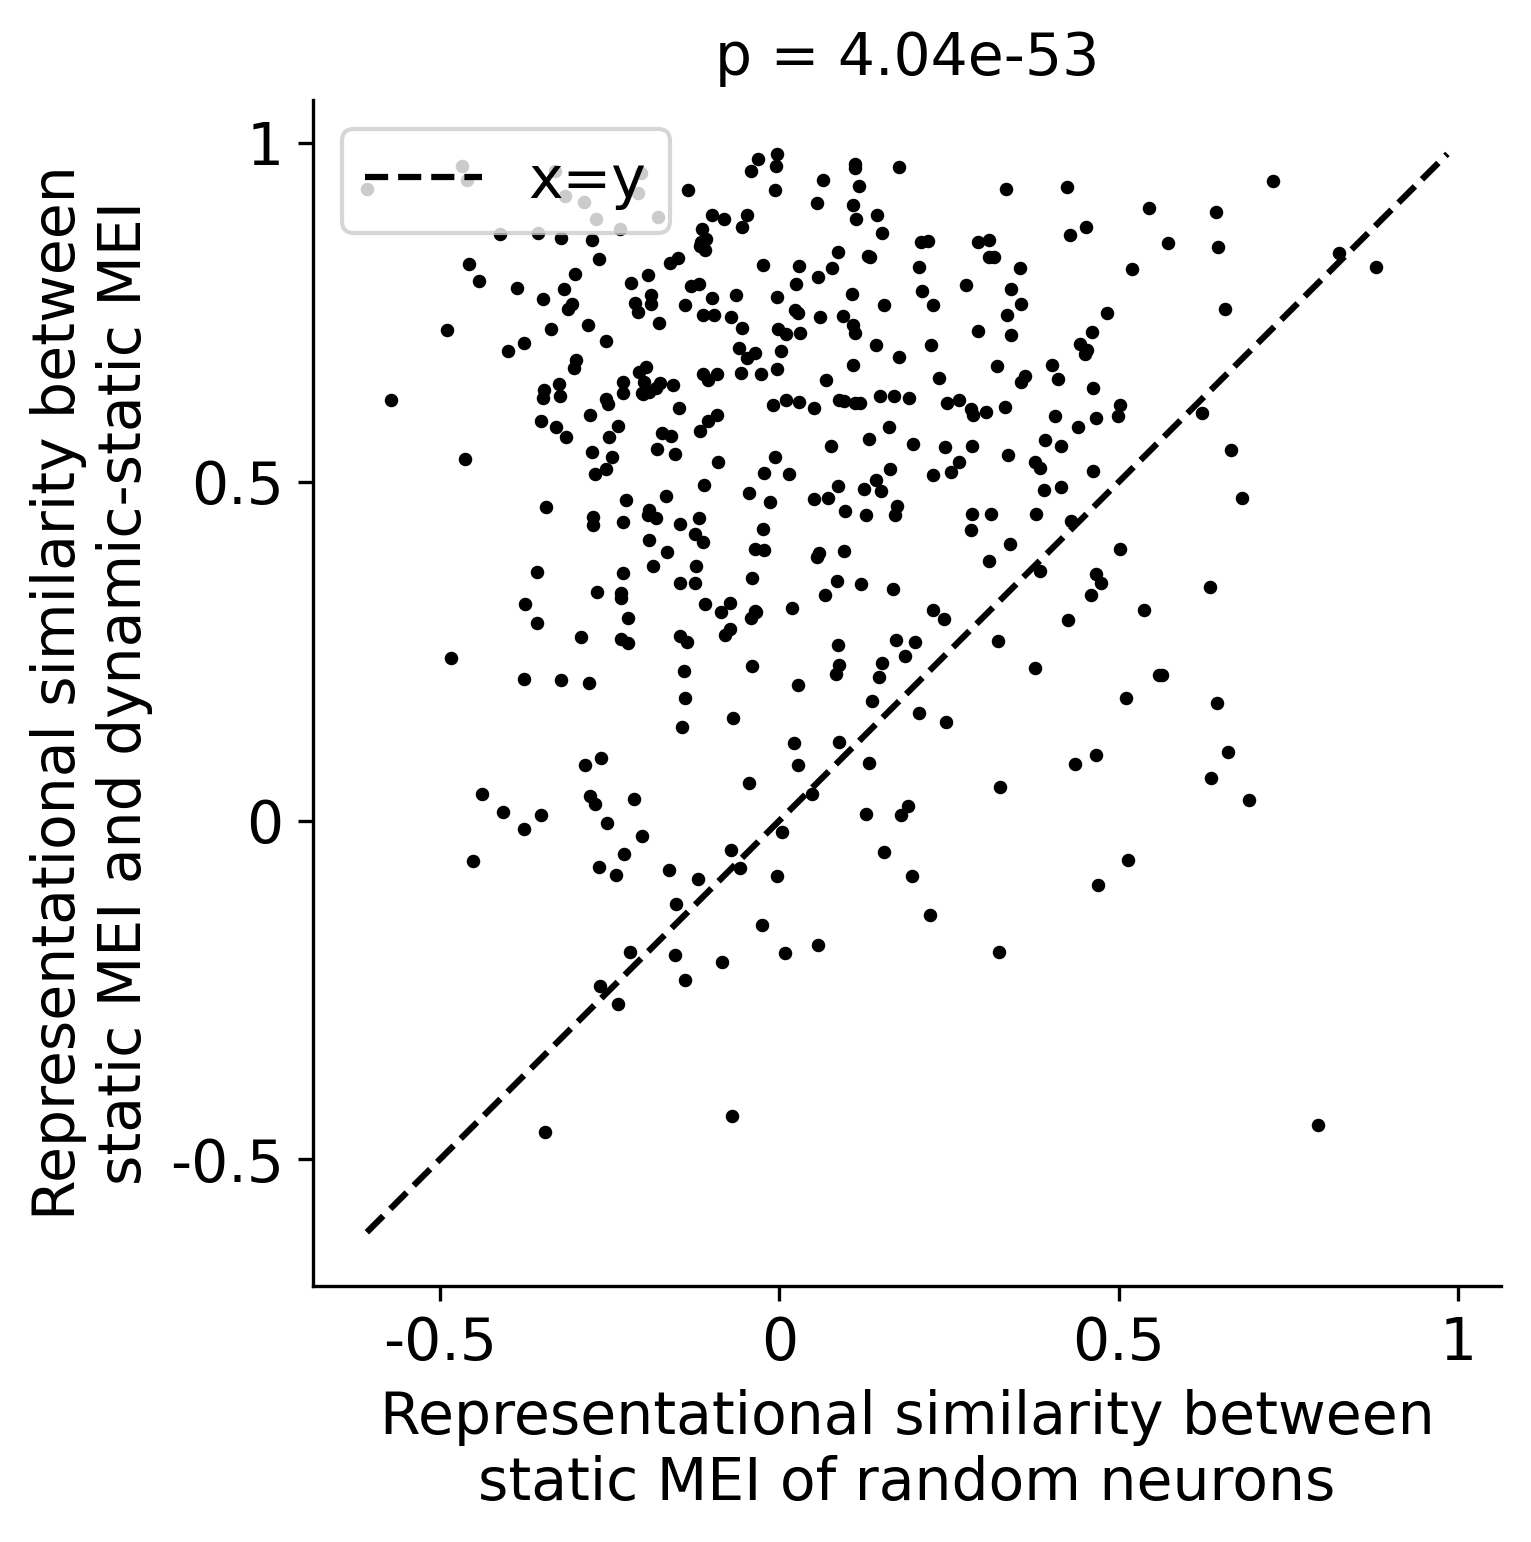

In [134]:
scatterplot_helper(mei_random_dists, mei_cross_dists[0, 1], 'Representational similarity between\nstatic MEI of random neurons', 'Representational similarity between\nstatic MEI and dynamic-static MEI', get_bound_from_data=True, fit=False, color='k', alpha=1)

plt.xticks([-0.5,0,0.5,1], [-0.5,0,0.5,1])
plt.yticks([-0.5,0,0.5,1], [-0.5,0,0.5,1])
plt.xlim([-0.5, 1])
plt.ylim([-0.5, 1])
plt.axis('equal')

p_wc = scipy.stats.wilcoxon(mei_random_dists, mei_cross_dists[0, 1])[1]
plt.title('p = {}'.format(np.format_float_scientific(p_wc, precision=2)), fontsize=14)

plt.savefig('/src/notebooks/Official_figures/[Fig6_e]Similarity_between_S_and_DS_MEI_scatter_version[verified_neurons].pdf', transparent=True)

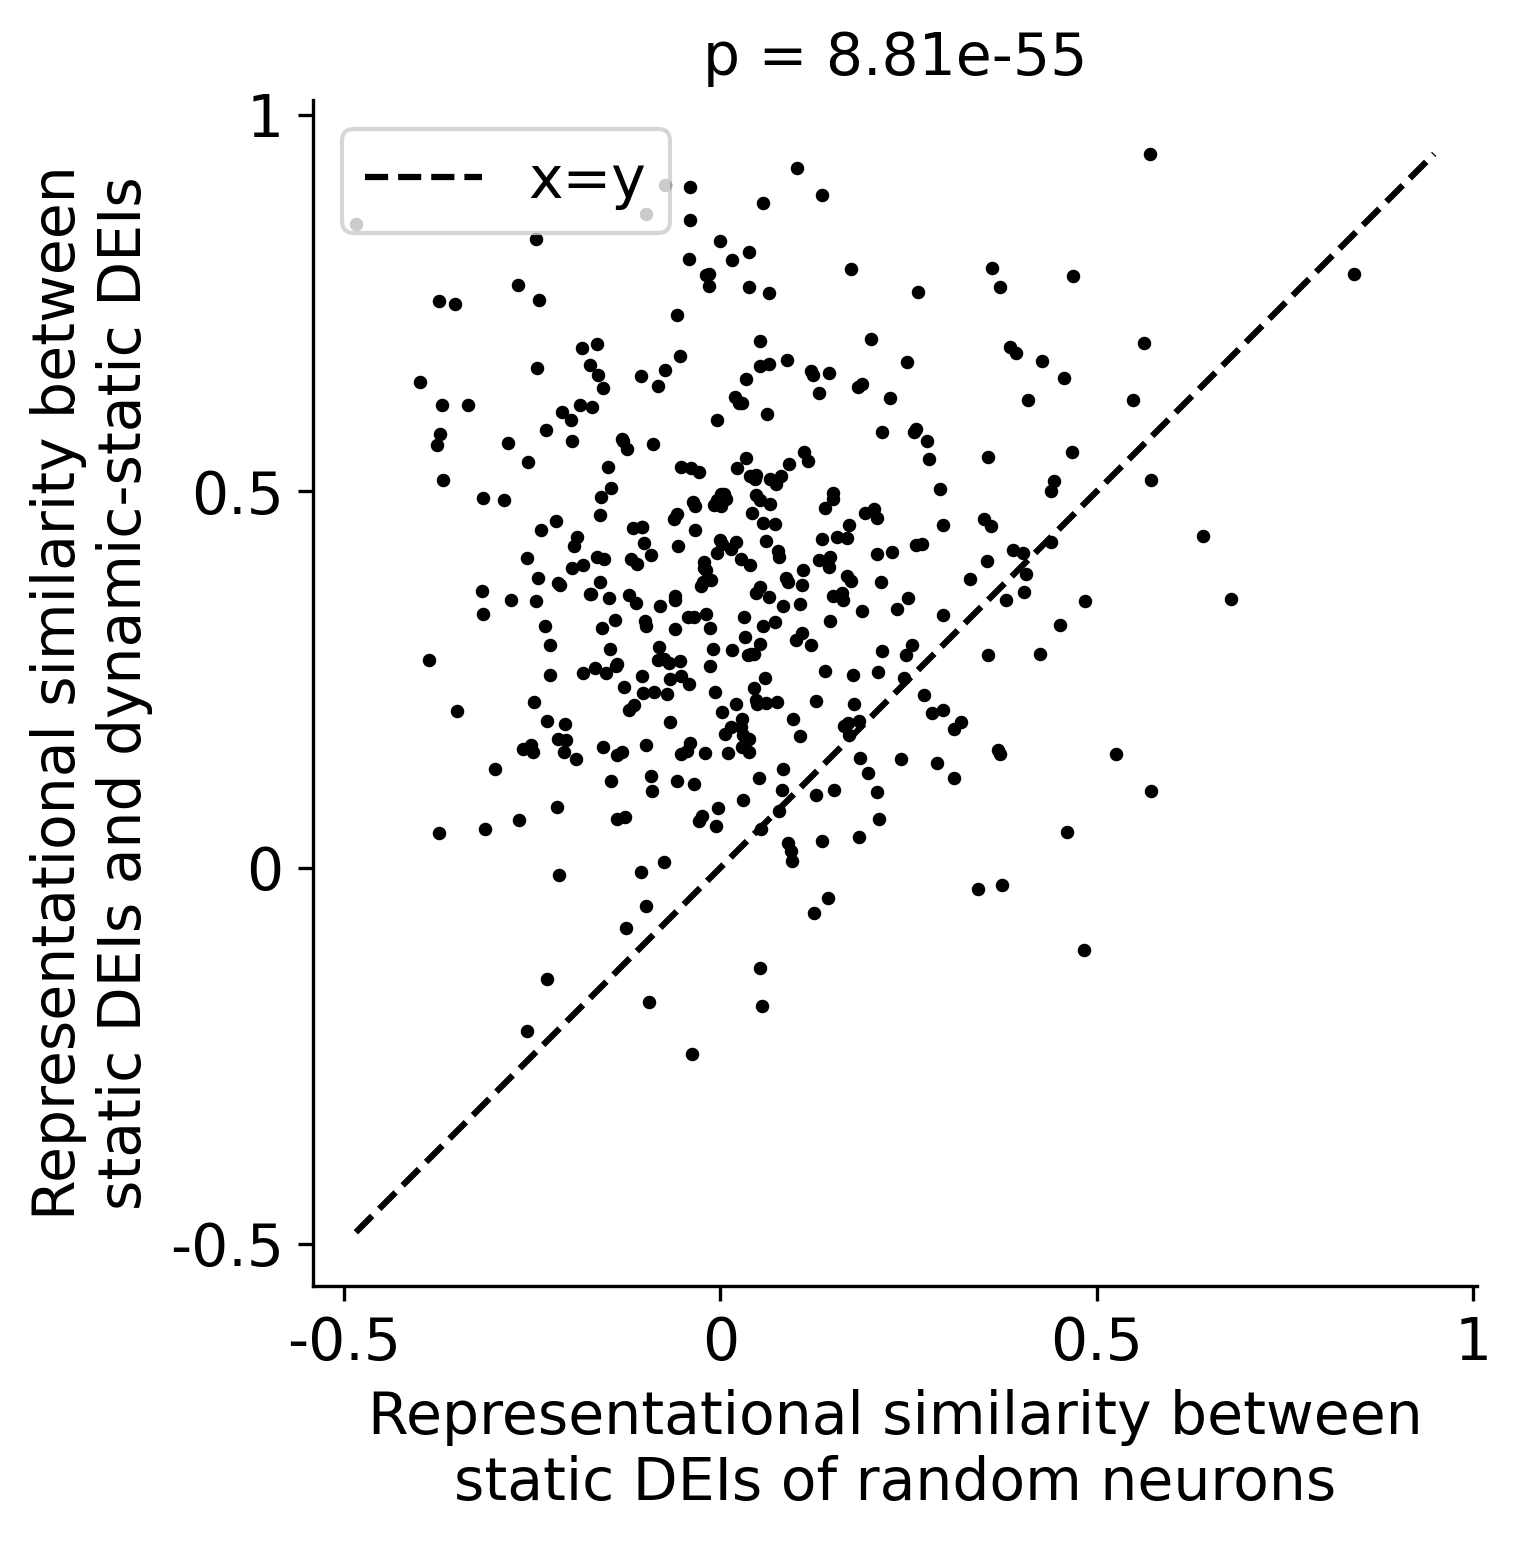

In [135]:
scatterplot_helper(random_dists, cross_dists[0, 1], 'Representational similarity between\nstatic DEIs of random neurons', 'Representational similarity between\nstatic DEIs and dynamic-static DEIs', get_bound_from_data=True, fit=False, color='k', alpha=1)
plt.xticks([-0.5,0,0.5,1], [-0.5,0,0.5,1])
plt.yticks([-0.5,0,0.5,1], [-0.5,0,0.5,1])
plt.xlim([-0.5, 1])
plt.ylim([-0.5, 1])
plt.axis('equal')

p_wc = scipy.stats.wilcoxon(random_dists, cross_dists[0, 1])[1]
plt.title('p = {}'.format(np.format_float_scientific(p_wc, precision=2)), fontsize=14)

plt.savefig('/src/notebooks/Official_figures/[Fig6_f]Similarity_between_S_and_DS_DEIs_scatter_version[verified_neurons].pdf', transparent=True)

# 6h, i

In [9]:
var = 'mei_sim'
x = (additional_data[var]-additional_data.groupby("pre_nucleus_id")[var].transform('mean'))
x = (x + additional_data[var].mean()).to_numpy()

y = (additional_data['n_synapses'] - additional_data['dend_len'] 
     * additional_data.groupby("pre_nucleus_id")['n_synapses'].transform("sum")
     /additional_data.groupby("pre_nucleus_id")['dend_len'].transform("sum"))

#y = (y + additional_data['n_synapses'].sum()/additional_data['dend_len'].sum()*additional_data['dend_len']).to_numpy()
idx = additional_data[additional_data['n_synapses'] > 0]['n_synapses'].to_numpy()

In [10]:
mei_corrected_result = bootstrap_bin(data=additional_data,var='mei_sim',corrected=True)
dei_corrected_result = bootstrap_bin(data=additional_data,var='dei_sim',corrected=True)

100%|██████████| 10000/10000 [00:56<00:00, 177.69it/s]


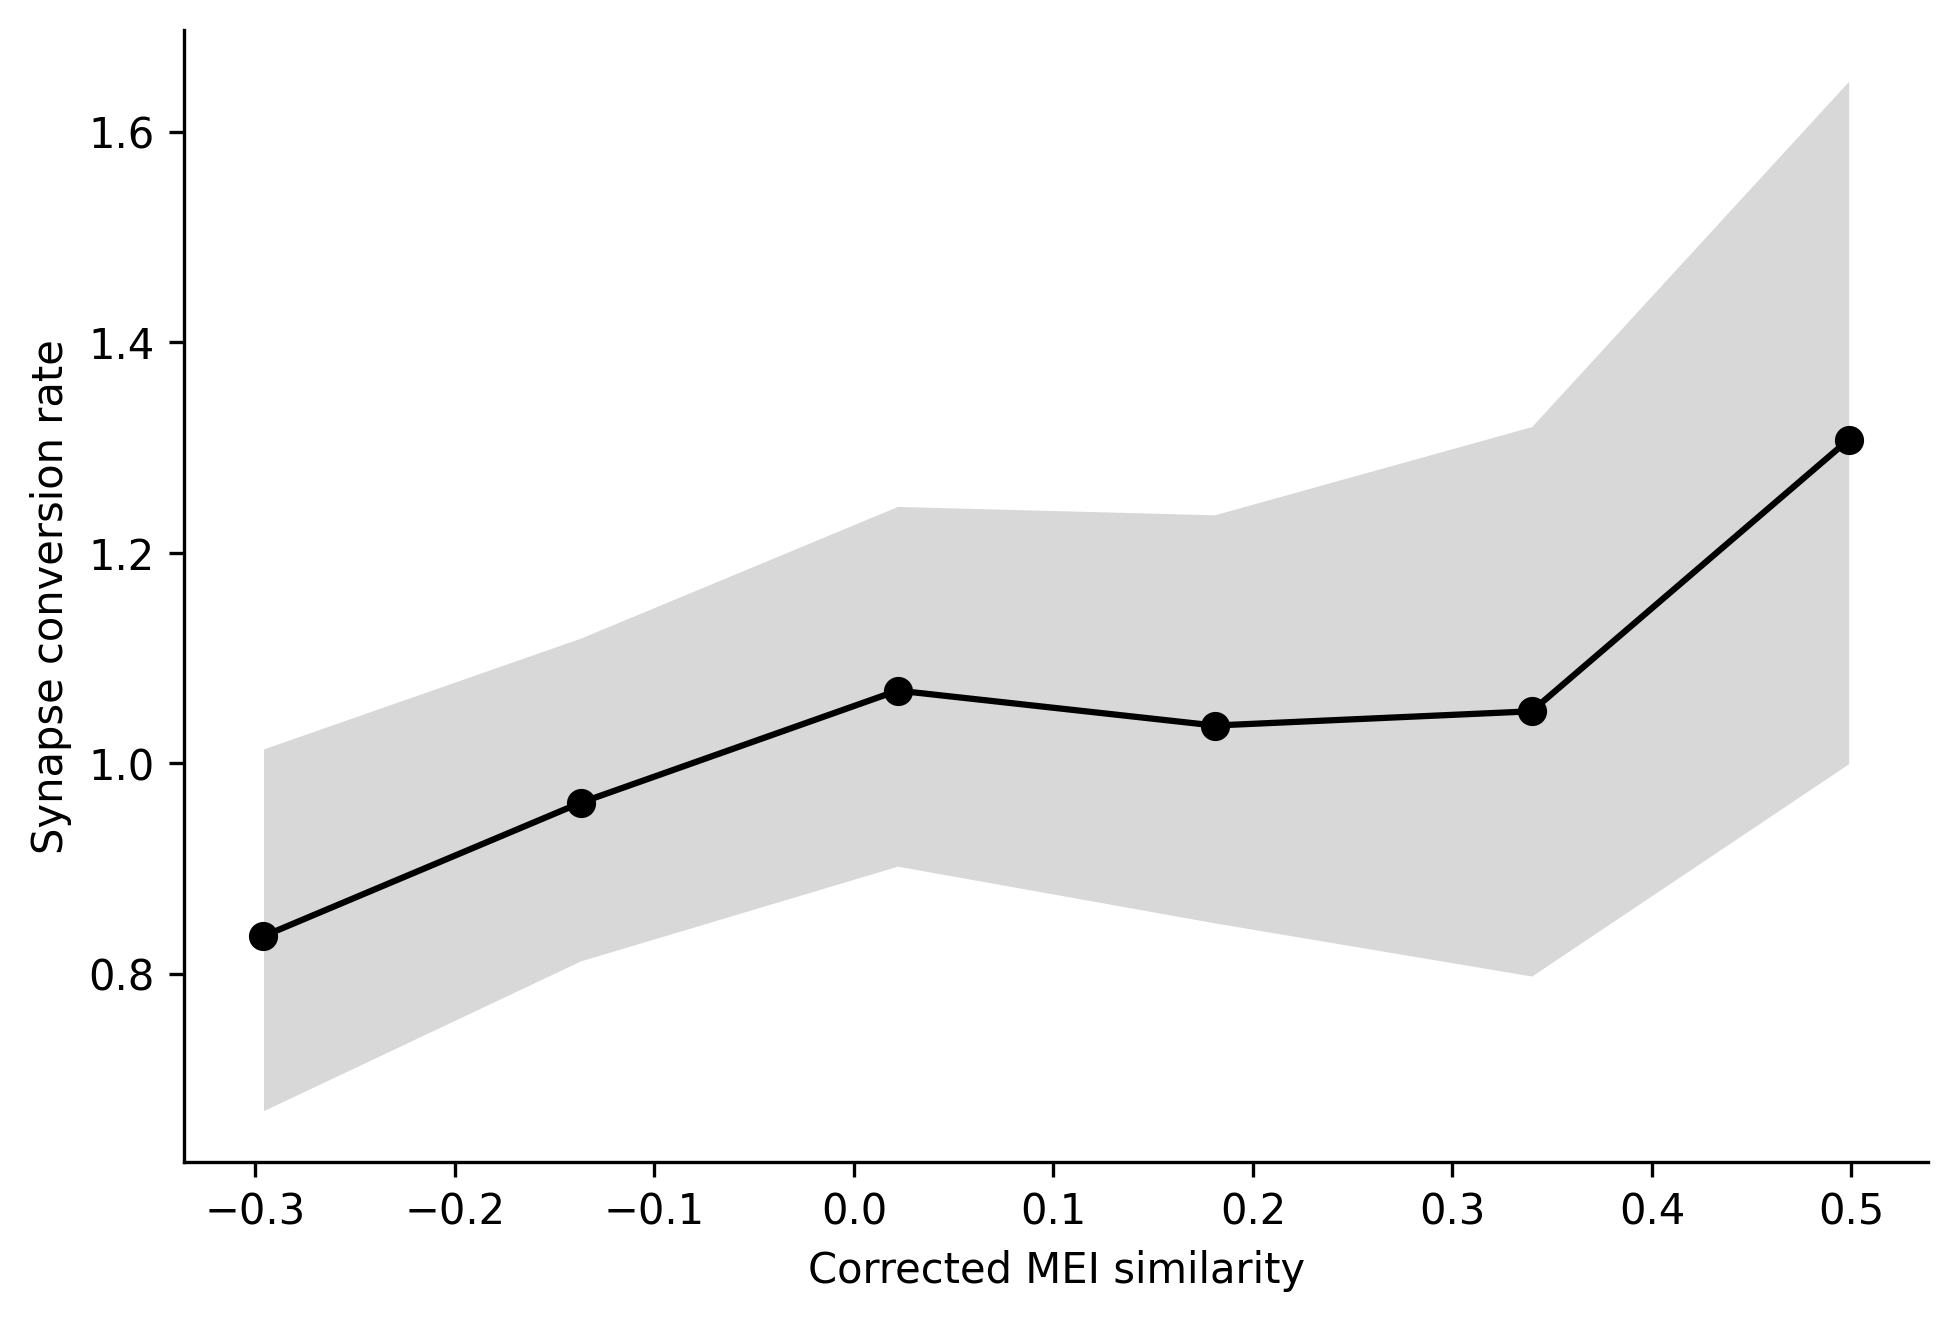

In [11]:
result = mei_corrected_result
xlabel = 'Corrected MEI similarity'
ylabel = 'Synapse conversion rate'
plt.figure(figsize=(7.5, 5), dpi=300)
ax = plt.gca()
plt.plot(result['x_center'],result['y_center'],c="k")
ax.fill_between(result['x_center'],result['y_CI'][:,0],result['y_CI'][:,1],alpha=0.3,color="gray",lw=0,)
plt.scatter(result['x_center'],result['y_center'],c="k")


sns.despine()
plt.xlabel(xlabel)
plt.ylabel(ylabel)

plt.savefig("fig_6_mei_rate.pdf",bbox_inches='tight',transparent=True,pad_inches = 0)

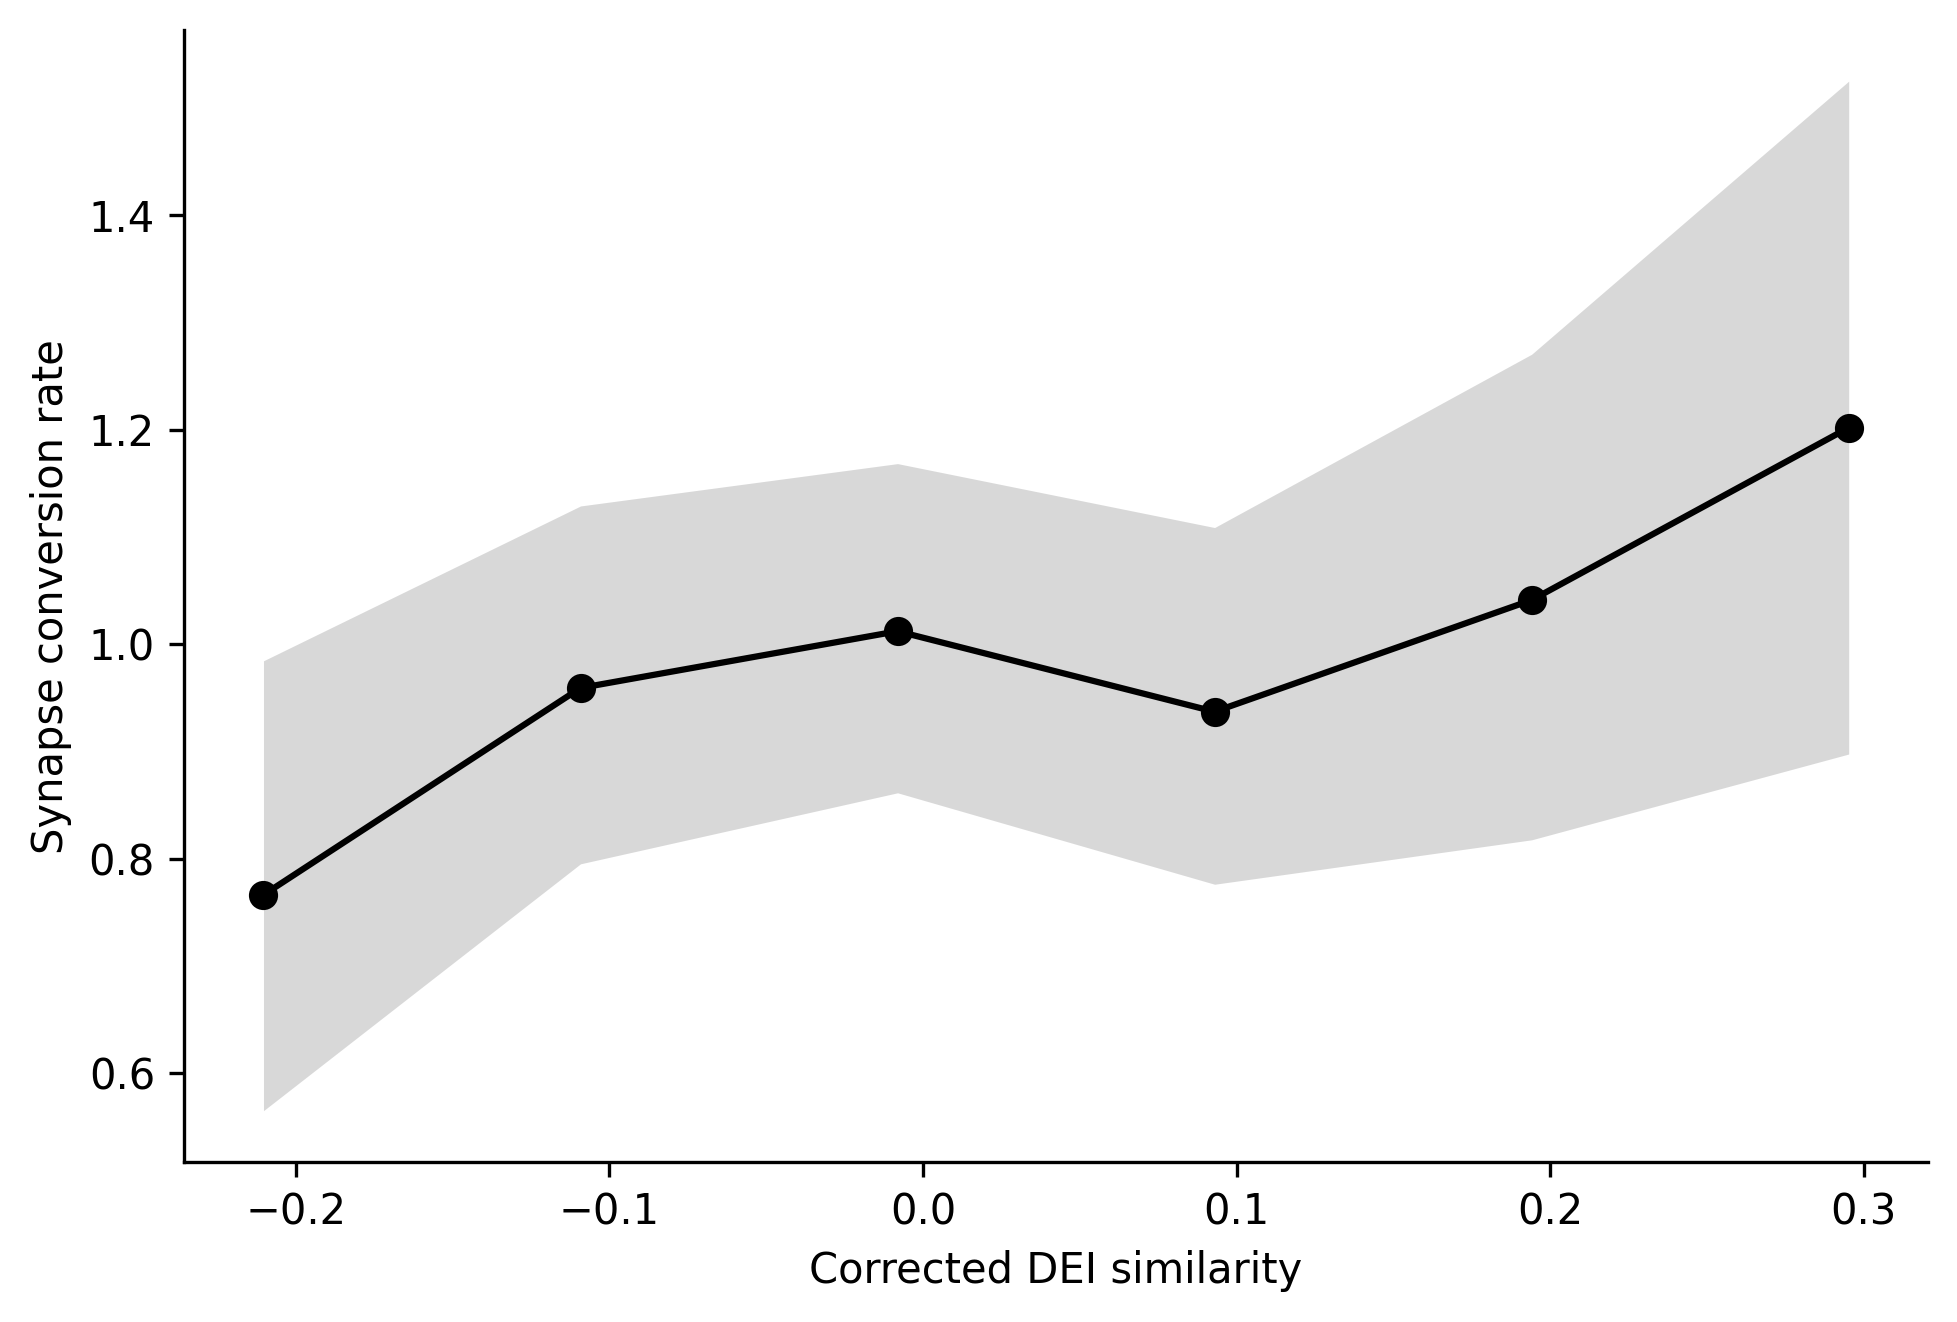

In [12]:
result = dei_corrected_result
xlabel = 'Corrected DEI similarity'
ylabel = 'Synapse conversion rate'
plt.figure(figsize=(7.5, 5), dpi=300)
ax = plt.gca()
plt.plot(result['x_center'],result['y_center'],c="k")
ax.fill_between(result['x_center'],result['y_CI'][:,0],result['y_CI'][:,1],alpha=0.3,color="gray",lw=0,)
plt.scatter(result['x_center'],result['y_center'],c="k")


sns.despine()
plt.xlabel(xlabel)
plt.ylabel(ylabel)

plt.savefig("fig_6_dei_rate.pdf",bbox_inches='tight',transparent=True,pad_inches = 0)

# 6g, k

In [14]:
corrected_mei_sim_connected,corrected_mei_sim_adp,corrected_mei_sim_p = bootstrap_comp(additional_data, var='mei_sim',corrected=True)
corrected_dei_sim_connected,corrected_dei_sim_adp,corrected_dei_sim_p = bootstrap_comp(additional_data, var='dei_sim',corrected=True)
corrected_delta_connected,corrected_delta_adp,corrected_delta_p = bootstrap_comp(additional_data, var='delta_avg_sim',corrected=True)

100%|██████████| 10000/10000 [00:04<00:00, 2063.58it/s]


In [15]:
print(corrected_mei_sim_p,corrected_dei_sim_p,corrected_delta_p)

0.02 0.0 0.04


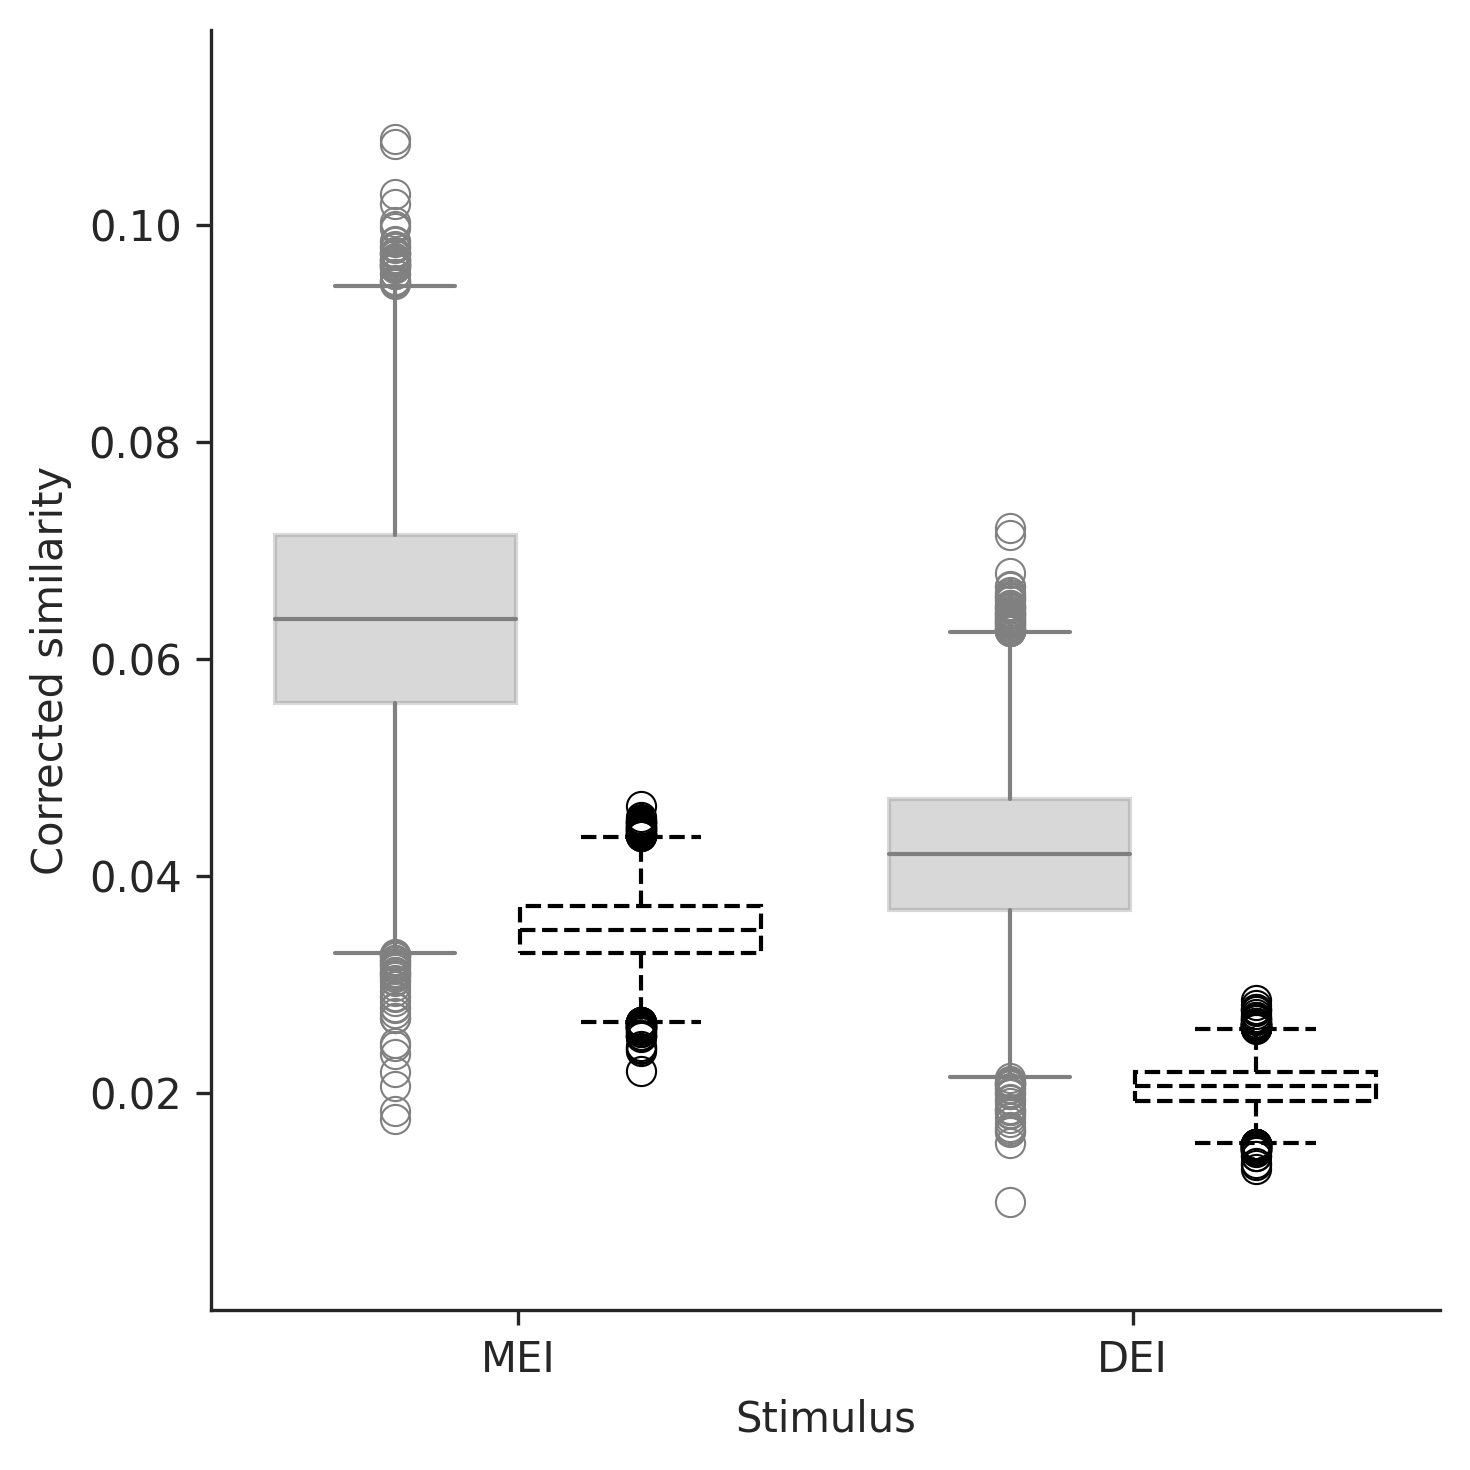

In [16]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Build DataFrame with correct ordering: Connected then ADP
df = pd.DataFrame({
    'Similarity': np.concatenate([
        corrected_mei_sim_connected,
        corrected_mei_sim_adp,
        corrected_dei_sim_connected,
        corrected_dei_sim_adp
    ]),
    'Stimulus': (
        ['MEI'] * (len(corrected_mei_sim_connected) + len(corrected_mei_sim_adp)) +
        ['DEI'] * (len(corrected_dei_sim_connected) + len(corrected_dei_sim_adp))
    ),
    'Condition': (
        ['Connected'] * len(corrected_mei_sim_connected) +
        ['ADP']       * len(corrected_mei_sim_adp) +
        ['Connected'] * len(corrected_dei_sim_connected) +
        ['ADP']       * len(corrected_dei_sim_adp)
    )
})

sns.set_style("white")
plt.figure(figsize=(5, 5), dpi=300)

ax = sns.boxplot(
    data=df,
    x='Stimulus',
    y='Similarity',
    hue='Condition',
    hue_order=['Connected', 'ADP'],
    palette=['gray', 'k'],       # placeholder: overrides below
    showcaps=True,
    boxprops={'linewidth': 1},
    whiskerprops={'linewidth': 1},
    capprops={'linewidth': 1},
    medianprops={'linewidth': 1},
    flierprops={
        'marker': 'o',
        'markersize': 7,
        'markerfacecolor': 'none',
        'markeredgecolor': 'gray',
        'markeredgewidth': 0.5
    }
)

# Ensure a white background and keep ticks
#ax.set_facecolor('white')
ax.tick_params(bottom=True, left=True)

# Style boxes: idx 0,2=Connected; idx 1,3=ADP
for idx, box in enumerate(ax.artists):
    if idx % 2 == 0:
        box.set_facecolor('gray')
        box.set_alpha(0.3)
        box.set_edgecolor('gray')
        box.set_linestyle('-')
    else:
        box.set_facecolor('none')
        box.set_edgecolor('black')
        box.set_linestyle('--')

# Style whiskers, caps, medians, and fliers
for line_idx, line in enumerate(ax.lines):
    box_idx = line_idx // 6
    part = line_idx % 6

    if part in [0, 1, 2, 3]:  # whiskers & caps
        if box_idx % 2 == 0:
            line.set_linestyle('-')
            line.set_color('gray')
        else:
            line.set_linestyle('--')
            line.set_color('black')
        line.set_linewidth(1)

    elif part == 4:  # median
        if box_idx % 2 == 0:
            line.set_linestyle('-')
            line.set_color('gray')
        else:
            line.set_linestyle('--')
            line.set_color('black')
        line.set_linewidth(1)

    elif part == 5:  # fliers
        if box_idx % 2 == 0:
            line.set_markeredgecolor('gray')
        else:
            line.set_markeredgecolor('black')
        line.set_markerfacecolor('none')
        line.set_markeredgewidth(0.5)
        line.set_markersize(7)

# Remove any legend
leg = ax.get_legend()
if leg:
    leg.remove()

plt.ylabel('Corrected similarity')
plt.ylim(df['Similarity'].min() - 0.01, df['Similarity'].max() + 0.01)

sns.despine()
plt.tight_layout()
plt.savefig("mei_dei_sim_boxplot.pdf", bbox_inches='tight', transparent=True, pad_inches=0)
plt.show()

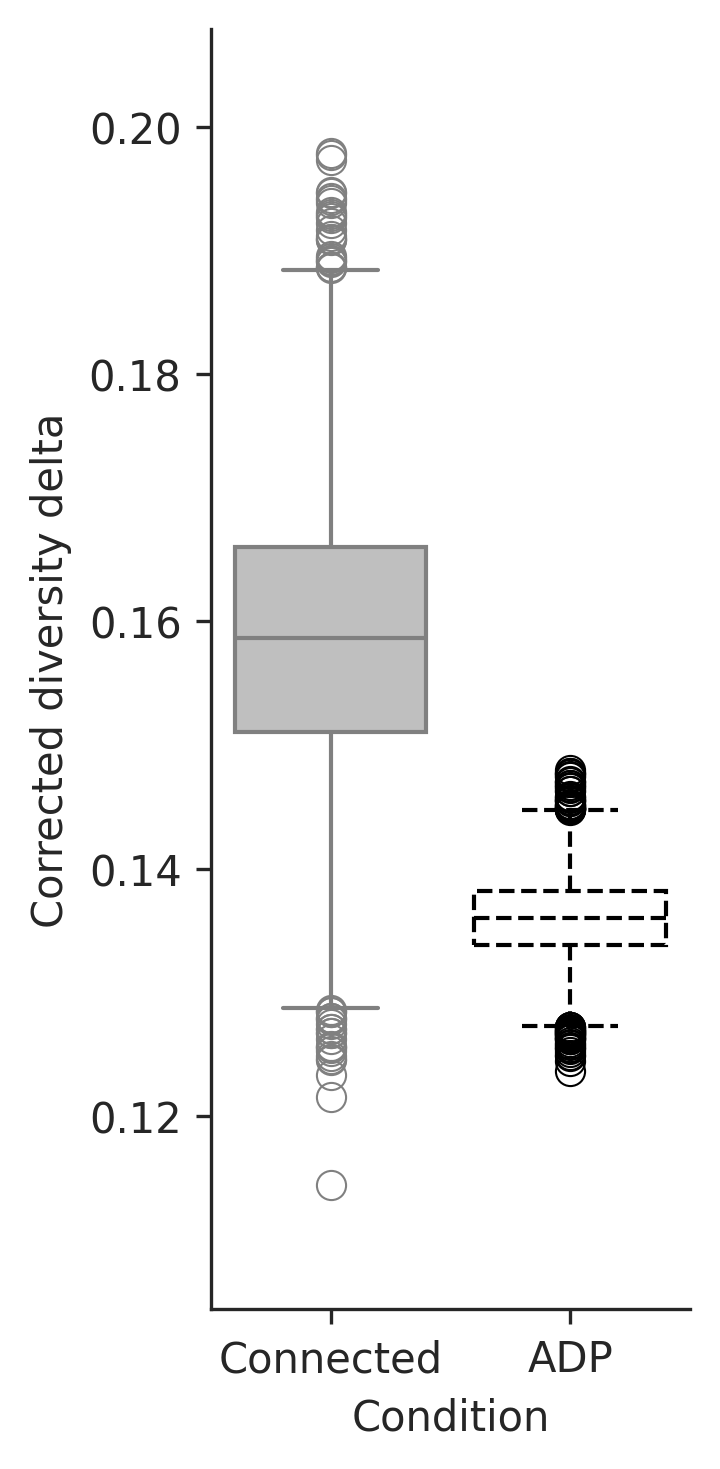

In [17]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Build the DataFrame for box‐plotting
df_delta = pd.DataFrame({
    'Delta': np.concatenate([
        corrected_delta_adp,
        corrected_delta_connected
    ]),
    'Condition': (['ADP'] * len(corrected_delta_adp) +
                  ['Connected'] * len(corrected_delta_connected))
})

plt.figure(figsize=(2.5, 5), dpi=300)
ax = sns.boxplot(
    data=df_delta,
    x='Condition',
    y='Delta',
    order=['Connected', 'ADP'],      # Connected first, then ADP
    palette=['gray', 'k'],
    showcaps=True,
    boxprops={'linewidth': 1},
    whiskerprops={'linewidth': 1},
    capprops={'linewidth': 1},
    medianprops={'linewidth': 1},
    flierprops={
        'marker': 'o',
        'markersize': 7,
        'markerfacecolor': 'none',
        'markeredgecolor': 'gray',
        'markeredgewidth': 0.5
    }
)
ax.tick_params(bottom=True, left=True)
# Style boxes: idx 0 = Connected; idx 1 = ADP
for idx, box in enumerate(ax.artists):
    if idx == 0:
        box.set_facecolor((0.5, 0.5, 0.5, 0.5))
        box.set_edgecolor('gray')
        box.set_linestyle('-')
    else:
        box.set_facecolor('none')
        box.set_edgecolor('black')
        box.set_linestyle('--')

# Style whiskers, caps, medians, and outliers
for line_idx, line in enumerate(ax.lines):
    box_idx = line_idx // 6
    part = line_idx % 6

    if part in [0, 1, 2, 3]:  # whiskers & caps
        if box_idx == 0:
            line.set_linestyle('-')
            line.set_color('gray')
        else:
            line.set_linestyle('--')
            line.set_color('black')
        line.set_linewidth(1)

    elif part == 4:  # median
        if box_idx == 0:
            line.set_linestyle('-')
            line.set_color('gray')
        else:
            line.set_linestyle('--')
            line.set_color('black')
        line.set_linewidth(1)

    elif part == 5:  # fliers
        if box_idx == 0:
            line.set_markeredgecolor('gray')
        else:
            line.set_markeredgecolor('black')
        line.set_markerfacecolor('none')
        line.set_markeredgewidth(0.5)
        line.set_markersize(7)

# Remove legend entirely
leg = ax.get_legend()
if leg:
    leg.remove()

plt.ylabel('Corrected diversity delta')
plt.ylim(df_delta['Delta'].min() - 0.01,
         df_delta['Delta'].max() + 0.01)

sns.despine()
plt.tight_layout()
plt.savefig("fig_6_delta_boxplot.pdf", bbox_inches='tight',
            transparent=True, pad_inches=0)
plt.show()


# 6j

In [20]:
# dynamic static model performance on static oracles
keys, ds_cc_abs, ds_cc_max, ds_cc_norm, ds_div, ds_p  = \
(base.DynamicStaticEnsembleEval.Unit * deis_schema.DEI * deis_schema.Texture & (deis_schema.TextureGoodRun & 'group_id in (344, 347, 363)') & \
neuron_rel.proj(group_id='dyn_group_id', neuron_id='dyn_neuron_id')
).fetch(dj.key, 'cc_abs', 'cc_max', 'cc_norm', 'avg_sim', 'p', order_by='group_id, neuron_id')

# static model performance on static oracles
sta_cc_abs, sta_cc_max, sta_cc_norm, sta_div, sta_p = \
((base.NewEnsembleEval.Unit & 'ssid = 1') * deis_schema.DEI * deis_schema.Texture * neuron_rel.proj(group_id='sta_group_id', neuron_id='sta_neuron_id') & \
(deis_schema.TextureGoodRun & 'group_id in (342, 346, 362)' & 'seed = 1009')
).fetch('cc_abs', 'cc_max', 'cc_norm', 'avg_sim', 'p', order_by='dyn_group_id, dyn_neuron_id')

# closed-loop verified neurons
verified_keys = \
(base.DynamicStaticEnsembleEval.Unit * deis_schema.DEI * deis_schema.Texture & (deis_schema.TextureGoodRun & 'group_id in (344, 347, 363)') & \
neuron_rel.proj(group_id='dyn_group_id', neuron_id='dyn_neuron_id')
).fetch(dj.key, order_by='group_id, neuron_id')

verified_idxs = []
for key in verified_keys:
    for i, k in enumerate(keys):
        if dict(group_id=key['group_id'], neuron_id=key['neuron_id']).items() < k.items():
            verified_idxs.append(i)

In [25]:
scipy.stats.pearsonr(deis_schema.convert_score(-sta_div)[verified_idxs], deis_schema.convert_score(-ds_div)[verified_idxs])

(0.46338779841693206, 1.2413598728960365e-22)

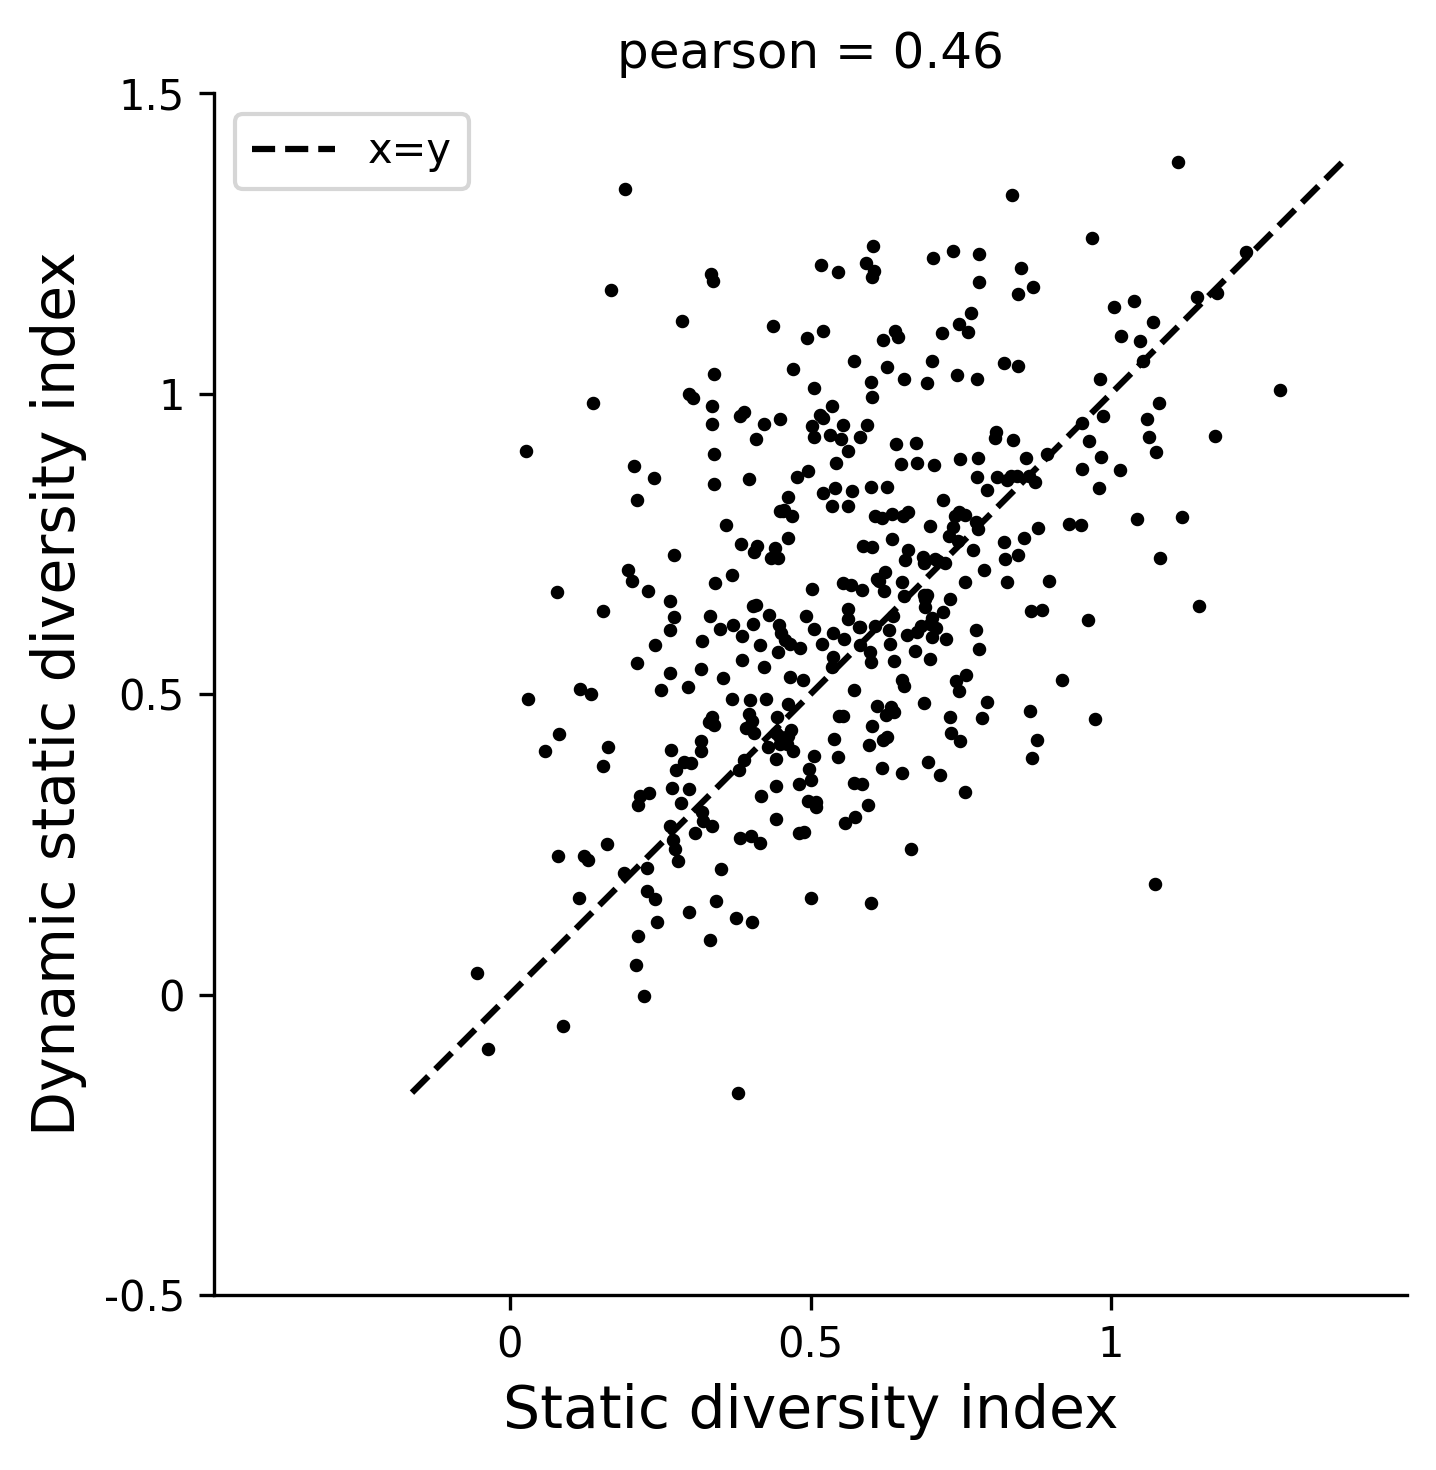

In [24]:
scatterplot_helper(deis_schema.convert_score(-sta_div)[verified_idxs], deis_schema.convert_score(-ds_div)[verified_idxs], 'Static diversity index', 'Dynamic static diversity index', get_bound_from_data=True, alpha=1, fit=False, color='k')
plt.axis('equal')
verified_pearson = scipy.stats.pearsonr(deis_schema.convert_score(-sta_div)[verified_idxs], deis_schema.convert_score(-ds_div)[verified_idxs])[0]
plt.title('pearson = {:.2f}'.format(verified_pearson))
plt.xticks([-0.5, 0, 0.5, 1, 1.5], [-0.5, 0, 0.5, 1, 1.5])
plt.yticks([-0.5, 0, 0.5, 1, 1.5], [-0.5, 0, 0.5, 1, 1.5])
plt.savefig('/src/notebooks/Official_figures/[Fig6_j]Diveristy_comparison_between_S_and_DS_DEIs_converted[verified_neurons].pdf', transparent=True)

# 6l

In [3]:
y = additional_data.groupby('pre_nucleus_id')['n_synapses'].sum()/(additional_data.groupby('pre_nucleus_id')['dend_len'].sum()/1e6)
x = additional_data.groupby('pre_nucleus_id')['pre_avg_sim'].mean()

In [4]:
def get_ll(model,X,y,sample_weight=None):
    from sklearn.metrics import log_loss
    y_pred = model.predict_proba(X)[:,1]
    return -log_loss(y, y_pred,sample_weight=sample_weight)*len(y)

def get_r2(model,X,y,sample_weight = None):
    from sklearn.metrics import r2_score
    y_pred = model.predict_proba(X)[:,1]
    return r2_score(y,y_pred,sample_weight=sample_weight)

def func(x, a, c, d):
    return a*np.exp(-c*x)+d 

def alt_funct(x,a,b):
    return ax+b
popt, pcov = curve_fit(func, x, y, p0=(3.9, 9.1,0.8))


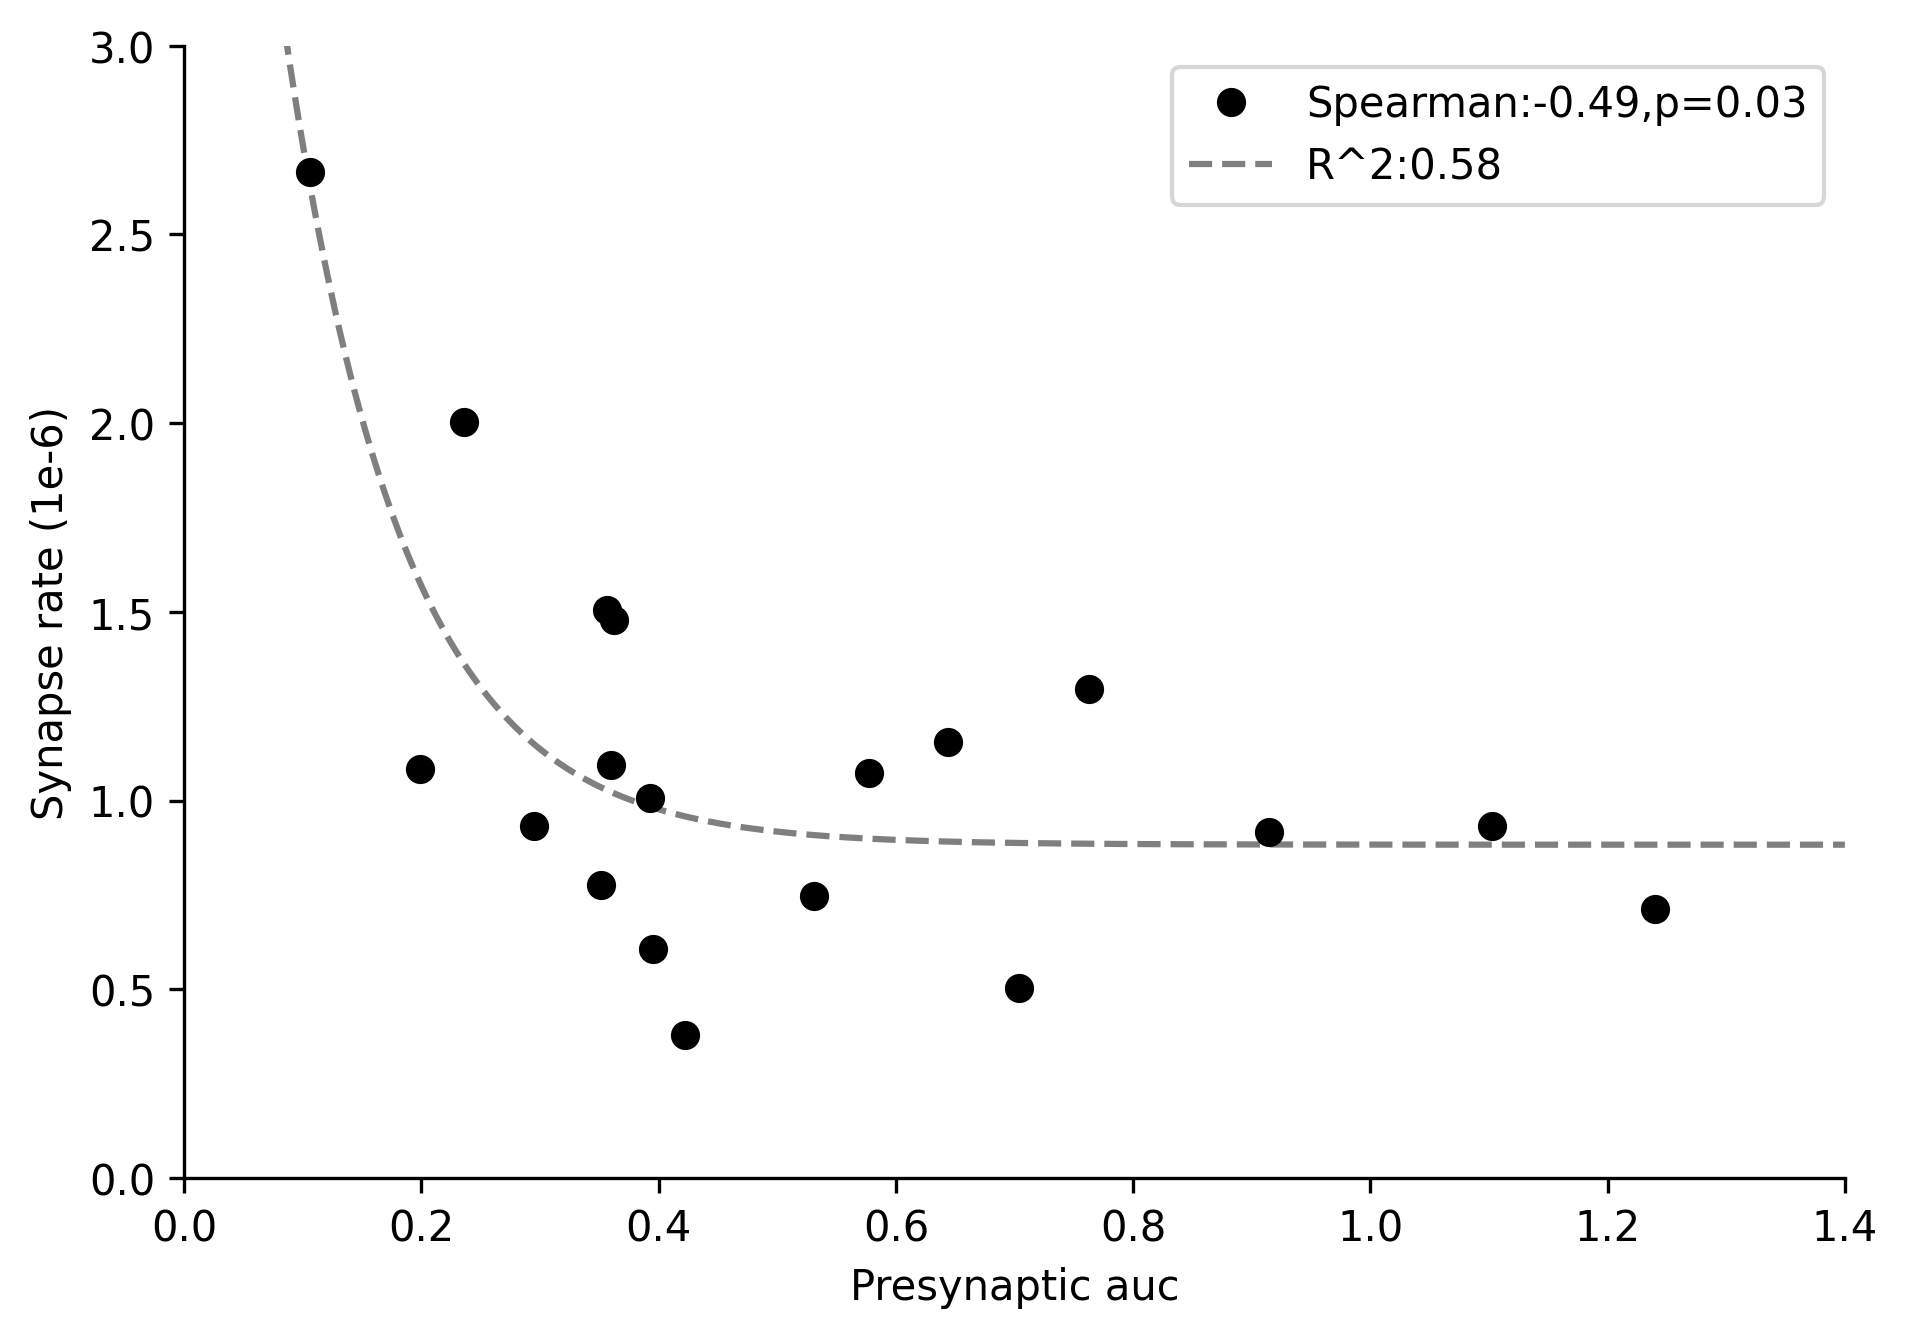

In [5]:
xx = np.linspace(0.001, 1.4, 1000)
yy = func(xx, *popt)
plt.figure(figsize=(5*5/3.5, 5), dpi=300)

plt.plot(x, y, 'ko',label='Spearman:{:.2f},p={:.2f}'.format(*spearmanr(x,y)))
plt.plot(xx, yy,linestyle='--',label='R^2:{:.2f}'.format(r2_score(y,func(x,*popt))),c='k',alpha=0.5)
plt.xlabel('Presynaptic auc')
plt.ylabel('Synapse rate (1e-6)')

plt.legend()
plt.xlim(0.0,1.4)
plt.ylim(0,3)
sns.despine()
plt.savefig("fig_6_div_synapse.pdf",bbox_inches='tight',transparent=True,pad_inches = 0)